<div align="center">
  <img src="../img/mcit_logo.png" alt="MCIT Logo" width="200" />
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="../img/depi_logo.png" alt="DEPI Logo" width="220" />
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="../img/eyouth_logo.png" alt="eYouth Logo" width="180" />
</div>

# Customer Churn Prediction: Machine Learning vs Deep Learning (ANN)

**Students:**
- Abdallah Mohamed Fahmy
- Abdelrahman Mahmoud Ahmed
- Abdlrhman Hisham Ismail
- Amgad Mohamed Mohamed
- Omar Tarek Emam
- Zyad Atef

**Date:** April 2026 

## Title + Metadata

- **Dataset:** IBM Telco Customer Churn (33-column version)
- **Dataset Source:** [Kaggle - yeanzc/telco-customer-churn-ibm-dataset](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset)
- **Local File Used:** `data/Telco_customer_churn.xlsx`
- **Problem Type:** Classification
- **Target Variable:** `Churn`
- **Primary Success Metric:** F1-score (focus on minority churn class)
- **Secondary Success Metric:** ROC-AUC

---
## Business + Problem Definition

### Why Customer Churn Matters (Business Impact)
Customer churn directly affects revenue, customer lifetime value, and acquisition costs. Retaining existing customers is usually cheaper than acquiring new ones, so early churn prediction helps telecom companies target at-risk customers with personalized retention actions.

### Project Objective
Build and compare **Machine Learning** and **Deep Learning (ANN)** models to predict whether a customer will churn.

### Inputs and Output
- **Input Features (`X`)**: Customer demographics, account information, service usage, contract/payment details, and billing-related features.
- **Output Target (`y`)**: `Churn` (binary classification)
  - `0` = No churn
  - `1` = Churn

### What Good Performance Means
Because churn prediction is an imbalanced classification problem, model quality is judged mainly by:
- **Primary metric: F1-score** on churn class (balances precision and recall)
- **Secondary metric: ROC-AUC** (overall ranking/separation quality)

A good model should improve detection of churners while controlling false alarms, making it practical for retention campaigns.

In [1]:
# Install dependencies (run once if needed)
!pip install -q xgboost tensorflow kagglehub[pandas-datasets] openpyxl

# ==============================
# 1) Standard library imports
# ==============================
import os
import random
import warnings
from time import perf_counter

# ==============================
# 2) Data manipulation imports
# ==============================
import numpy as np
import pandas as pd

# ==============================
# 3) Visualization imports
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 4) Machine learning imports
# ==============================
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve, auc,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

# ==============================
# 5) Deep learning imports
# ==============================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam

# ==============================
# 6) Reproducibility settings
# ==============================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==============================
# 7) Display and warning settings
# ==============================
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
warnings.filterwarnings("ignore")

# ==============================
# 8) Package versions (optional reproducibility log)
# ==============================
print("Python random seed:", SEED)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("seaborn:", sns.__version__)
print("tensorflow:", tf.__version__)

import sklearn
import xgboost
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

zsh:1: no matches found: kagglehub[pandas-datasets]


I0000 00:00:1776401913.030884   13932 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776401913.211794   13932 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776401914.175462   13932 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python random seed: 42
numpy: 2.3.5
pandas: 2.3.3
seaborn: 0.13.2
tensorflow: 2.21.0
scikit-learn: 1.8.0
xgboost: 3.2.0


---
## Data Reading

We use the **IBM Telco Customer Churn** dataset (**7,043 rows × 33 columns**).

Data loading strategy:
1. Load local file first: `data/Telco_customer_churn.xlsx`
2. If local file is missing, load from KaggleHub dataset: `yeanzc/telco-customer-churn-ibm-dataset`

In [2]:
from pathlib import Path
import kagglehub
from kagglehub import KaggleDatasetAdapter

local_file = Path('../data/Telco_customer_churn.xlsx')

if local_file.exists():
    df = pd.read_excel(local_file)
    data_source = str(local_file)
else:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'yeanzc/telco-customer-churn-ibm-dataset',
        ''
    )
    data_source = 'kagglehub: yeanzc/telco-customer-churn-ibm-dataset'

print(f'Data source: {data_source}')
print(f'Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head()

Data source: ../data/Telco_customer_churn.xlsx
Dataset Shape: 7,043 rows × 33 columns
Columns (33): ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


---
## Data Understanding

In this section we inspect the dataset structure, statistical summary, missing values, class imbalance in the target, and key feature types.

In [3]:
# -------------------------------
# Data structure inspection
# -------------------------------
# Print a compact schema view: row count, column count, non-null counts, and data types.
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Int

In [4]:
# -------------------------------
# Descriptive statistics
# -------------------------------
# Show summary statistics for numeric columns (count, mean, std, quartiles, min, max).
print('\n=== Numerical Summary ===')
display(df.describe().T)

# Show summary statistics for categorical/text columns (count, unique, top, frequency).
print('\n=== Categorical Summary ===')
display(df.describe(include='object').T)


=== Numerical Summary ===


,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000



=== Categorical Summary ===


,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"32.67102, -117.095235",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [5]:
# -------------------------------
# Missing values summary
# -------------------------------
# Count missing values per column and sort descending to prioritize data quality fixes.
missing = df.isna().sum().sort_values(ascending=False)

# Keep only columns that actually contain missing values.
missing = missing[missing > 0]

print('\n=== Missing Values Summary ===')
if missing.empty:
    # Explicitly report clean state when no missing values are present.
    print('No missing values found.')
else:
    # Build a readable table with absolute and percentage missingness.
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Missing %': (missing / len(df) * 100).round(2)
    })
    display(missing_df)


=== Missing Values Summary ===


,Missing Count,Missing %
Churn Reason,5174,73.46


In [6]:
# -------------------------------
# Target distribution (imbalance check)
# -------------------------------
# Validate class balance using the raw target column from this dataset version.
print('\n=== Target Distribution (Churn Value) ===')

if 'Churn Value' in df.columns:
    # Count class frequencies and keep class order as 0 -> 1.
    target_counts = df['Churn Value'].value_counts().sort_index()

    # Convert frequencies to percentages for easier business interpretation.
    target_pct = (target_counts / target_counts.sum() * 100).round(2)

    # Combine counts and percentages in a single table.
    target_table = pd.DataFrame({
        'Count': target_counts,
        'Percentage %': target_pct
    })
    display(target_table)

    # Report churn prevalence (class 1) as the key imbalance indicator.
    churn_rate = target_pct.get(1, 0.0)
    print(f'Churn rate: {churn_rate:.2f}%')
else:
    # Provide a clear message if target naming changed unexpectedly.
    print("Column 'Churn Value' not found. Check target mapping step.")


=== Target Distribution (Churn Value) ===


,Count,Percentage %
Churn Value,,
0,5174,73.46
1,1869,26.54


Churn rate: 26.54%


In [7]:
# -------------------------------
# Data type overview
# -------------------------------
# Aggregate data types to quickly understand schema composition.
print('\n=== Data Types Overview ===')

dtype_summary = (
    df.dtypes
    .astype(str)
    .value_counts()
    .rename_axis('dtype')
    .reset_index(name='count')
)

display(dtype_summary)


=== Data Types Overview ===


,dtype,count
0,object,24
1,int64,6
2,float64,3


### Key Columns and Data Types (Interpretation)

- **Customer identity/location columns:** `CustomerID`, `Country`, `State`, `City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude`
  - Useful for profiling and regional analysis, but some may be dropped later to avoid overfitting/noise.
- **Demographic/account columns:** `Gender`, `Senior Citizen`, `Partner`, `Dependents`, `Tenure Months`
  - Important for understanding customer segments and lifecycle stage.
- **Service and contract columns:** `Phone Service`, `Internet Service`, `Contract`, `Payment Method`, and related add-on services
  - Strong business drivers of churn behavior.
- **Financial columns:** `Monthly Charges`, `Total Charges`, `CLTV`
  - Help capture value and pricing-pressure effects.
- **Target and leakage-related columns:** `Churn Value`, `Churn Label`, `Churn Score`, `Churn Reason`
  - `Churn Value` is the supervised target.
  - `Churn Label`, `Churn Score`, and `Churn Reason` can leak target information and should be excluded during model training.

---
## Data Cleaning

This step standardizes the 33-column schema to match our modeling pipeline, handles data quality issues, removes leakage fields, and creates a clean dataset for modeling.

In [8]:
# -------------------------------
# Data cleaning setup + schema normalization
# -------------------------------
# Define mapping from raw 33-column names to pipeline-compatible feature names.
column_rename_map = {
    'CustomerID': 'customerID',
    'Gender': 'gender',
    'Senior Citizen': 'SeniorCitizen',
    'Tenure Months': 'tenure',
    'Phone Service': 'PhoneService',
    'Multiple Lines': 'MultipleLines',
    'Internet Service': 'InternetService',
    'Online Security': 'OnlineSecurity',
    'Online Backup': 'OnlineBackup',
    'Device Protection': 'DeviceProtection',
    'Tech Support': 'TechSupport',
    'Streaming TV': 'StreamingTV',
    'Streaming Movies': 'StreamingMovies',
    'Paperless Billing': 'PaperlessBilling',
    'Payment Method': 'PaymentMethod',
    'Monthly Charges': 'MonthlyCharges',
    'Total Charges': 'TotalCharges',
}

# Define leakage columns that must be removed before modeling.
leakage_columns = ['Churn Label', 'Churn Score', 'Churn Reason', 'Count']

# Create a dedicated cleaned dataframe copy and store initial shape.
df_clean = df.copy()
before_shape = df_clean.shape

# Apply column normalization and track how many columns were renamed.
rename_hits = [c for c in column_rename_map if c in df_clean.columns]
df_clean.rename(columns=column_rename_map, inplace=True)

print(f'Initial shape: {before_shape[0]:,} rows × {before_shape[1]} columns')
print(f'Columns normalized: {len(rename_hits)}')

Initial shape: 7,043 rows × 33 columns
Columns normalized: 17


In [9]:
# -------------------------------
# Step 1: Handle TotalCharges conversion and null removal
# -------------------------------
# Convert TotalCharges to numeric safely; invalid values become NaN.
if 'TotalCharges' in df_clean.columns:
    df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

    # Count rows that became null after conversion.
    totalcharges_nulls = int(df_clean['TotalCharges'].isna().sum())

    # Remove rows with null TotalCharges to keep modeling input valid.
    df_clean.dropna(subset=['TotalCharges'], inplace=True)
else:
    totalcharges_nulls = 0

print('=== TotalCharges Cleaning ===')
print(f'Rows removed due to null TotalCharges: {totalcharges_nulls}')
print(f'Shape after TotalCharges handling: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

=== TotalCharges Cleaning ===
Rows removed due to null TotalCharges: 11
Shape after TotalCharges handling: 7,032 rows × 33 columns


In [10]:
# -------------------------------
# Step 2: Remove duplicates and non-modeling/leakage columns
# -------------------------------
# Count duplicates before removal for reporting.
duplicates_before = int(df_clean.duplicated().sum())

# Remove exact duplicate rows.
df_clean.drop_duplicates(inplace=True)

# Remove customer identifier (unique ID; not predictive).
if 'customerID' in df_clean.columns:
    df_clean.drop(columns=['customerID'], inplace=True)

# Drop leakage columns that reveal or strongly proxy the target.
leakage_dropped = [col for col in leakage_columns if col in df_clean.columns]
if leakage_dropped:
    df_clean.drop(columns=leakage_dropped, inplace=True)

# Drop non-predictive / high-cardinality geographic columns.
# These explode the feature space after one-hot encoding (thousands of dummies
# for City / Lat Long / Zip Code) and add no business signal beyond noise since
# every customer in this dataset is in California.
geo_columns = ['Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
geo_dropped = [col for col in geo_columns if col in df_clean.columns]
if geo_dropped:
    df_clean.drop(columns=geo_dropped, inplace=True)

print('=== Duplicate and Leakage Cleaning ===')
print(f'Duplicates removed: {duplicates_before}')
print('Leakage columns dropped:', leakage_dropped if leakage_dropped else 'None')
print('Geographic columns dropped:', geo_dropped if geo_dropped else 'None')
print(f'Shape after duplicate/leakage cleanup: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')

=== Duplicate and Leakage Cleaning ===
Duplicates removed: 0
Leakage columns dropped: ['Churn Label', 'Churn Score', 'Churn Reason', 'Count']
Geographic columns dropped: ['Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
Shape after duplicate/leakage cleanup: 7,032 rows × 21 columns


In [11]:
# -------------------------------
# Step 3: Target harmonization + before/after summary
# -------------------------------
# Standardize target to a single pipeline column named `Churn`.
if 'Churn Value' in df_clean.columns:
    # Preferred target in the 33-column schema (already numeric 0/1).
    df_clean['Churn'] = df_clean['Churn Value'].astype(int)
    df_clean.drop(columns=['Churn Value'], inplace=True)
elif 'Churn' in df_clean.columns:
    # Fallback for legacy schema where target may be text labels Yes/No.
    if df_clean['Churn'].dtype == object:
        df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)
    else:
        df_clean['Churn'] = df_clean['Churn'].astype(int)
else:
    raise KeyError("Target column not found. Expected 'Churn Value' or 'Churn'.")

# Capture final shape after all cleaning operations.
after_shape = df_clean.shape

# Build a concise before/after table for rows and columns.
before_after = pd.DataFrame({
    'Stage': ['Before Cleaning', 'After Cleaning'],
    'Rows': [before_shape[0], after_shape[0]],
    'Columns': [before_shape[1], after_shape[1]],
})

# Build a concise action log table for the main cleaning operations.
actions_summary = pd.DataFrame({
    'Action': [
        'Columns normalized',
        'Rows removed from TotalCharges nulls',
        'Duplicate rows removed',
        'Leakage columns dropped',
        'Geographic columns dropped',
    ],
    'Details': [
        f'{len(rename_hits)} columns',
        f'{totalcharges_nulls} rows',
        f'{duplicates_before} rows',
        ', '.join(leakage_dropped) if leakage_dropped else 'None',
        ', '.join(geo_dropped) if geo_dropped else 'None',
    ],
})

print('=== Before vs After (Rows/Columns) ===')
display(before_after)

print('\n=== Cleaning Actions Summary ===')
display(actions_summary)

print('\n=== Clean Dataset Preview ===')
display(df_clean.head())

print('\n=== Clean Target Distribution ===')
print(df_clean['Churn'].value_counts())

=== Before vs After (Rows/Columns) ===


,Stage,Rows,Columns
0,Before Cleaning,7043,33
1,After Cleaning,7032,21



=== Cleaning Actions Summary ===


,Action,Details
0,Columns normalized,17 columns
1,Rows removed from TotalCharges nulls,11 rows
2,Duplicate rows removed,0 rows
3,Leakage columns dropped,"Churn Label, Churn Score, Churn Reason, Count"
4,Geographic columns dropped,"Country, State, City, Zip Code, Lat Long, Lati..."



=== Clean Dataset Preview ===


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,CLTV,Churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,3239,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,2701,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,5372,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,5003,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,5340,1



=== Clean Target Distribution ===
Churn
0    5163
1    1869
Name: count, dtype: int64


---
## Exploratory Data Analysis (EDA)

This section explores churn behavior through four required visual checks:
- Target distribution
- Numeric feature distributions
- Categorical churn-rate patterns
- Correlation heatmap

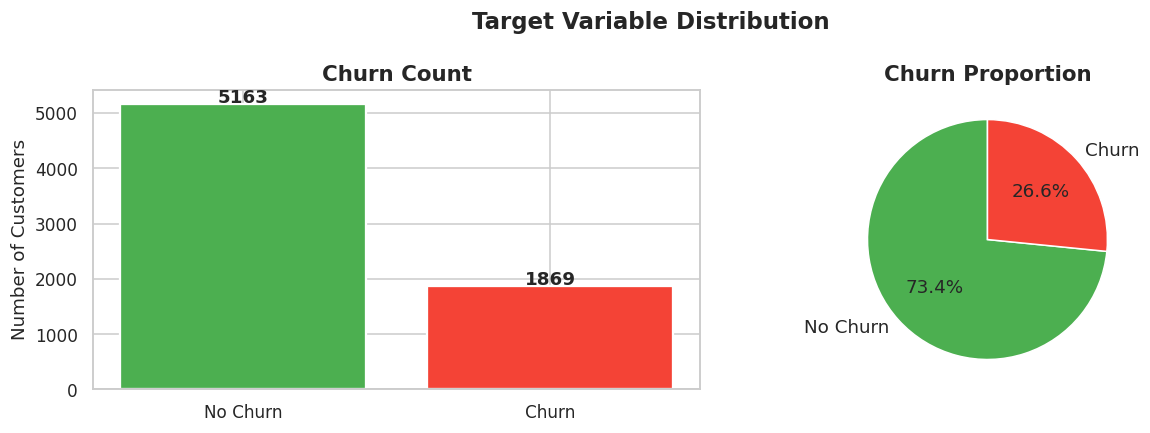

Churn rate: 26.58% (imbalanced dataset)


In [12]:
# -------------------------------
# EDA setup
# -------------------------------
# Use cleaned data for all exploratory analysis to ensure consistency with modeling.
eda_df = df_clean.copy()

# Verify target exists before plotting.
if 'Churn' not in eda_df.columns:
    raise KeyError("`Churn` column is missing from cleaned dataset.")

# -------------------------------
# 1) Target distribution plot
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compute class counts for churn vs non-churn.
counts = eda_df['Churn'].value_counts().sort_index()
labels = ['No Churn', 'Churn']
colors = ['#4CAF50', '#F44336']

# Left panel: absolute class counts.
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, value in enumerate(counts.values):
    axes[0].text(i, value + 30, str(value), ha='center', fontweight='bold')

# Right panel: class proportions.
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Report churn rate explicitly for metric-choice justification.
churn_rate = counts.get(1, 0) / counts.sum() * 100
print(f'Churn rate: {churn_rate:.2f}% (imbalanced dataset)')

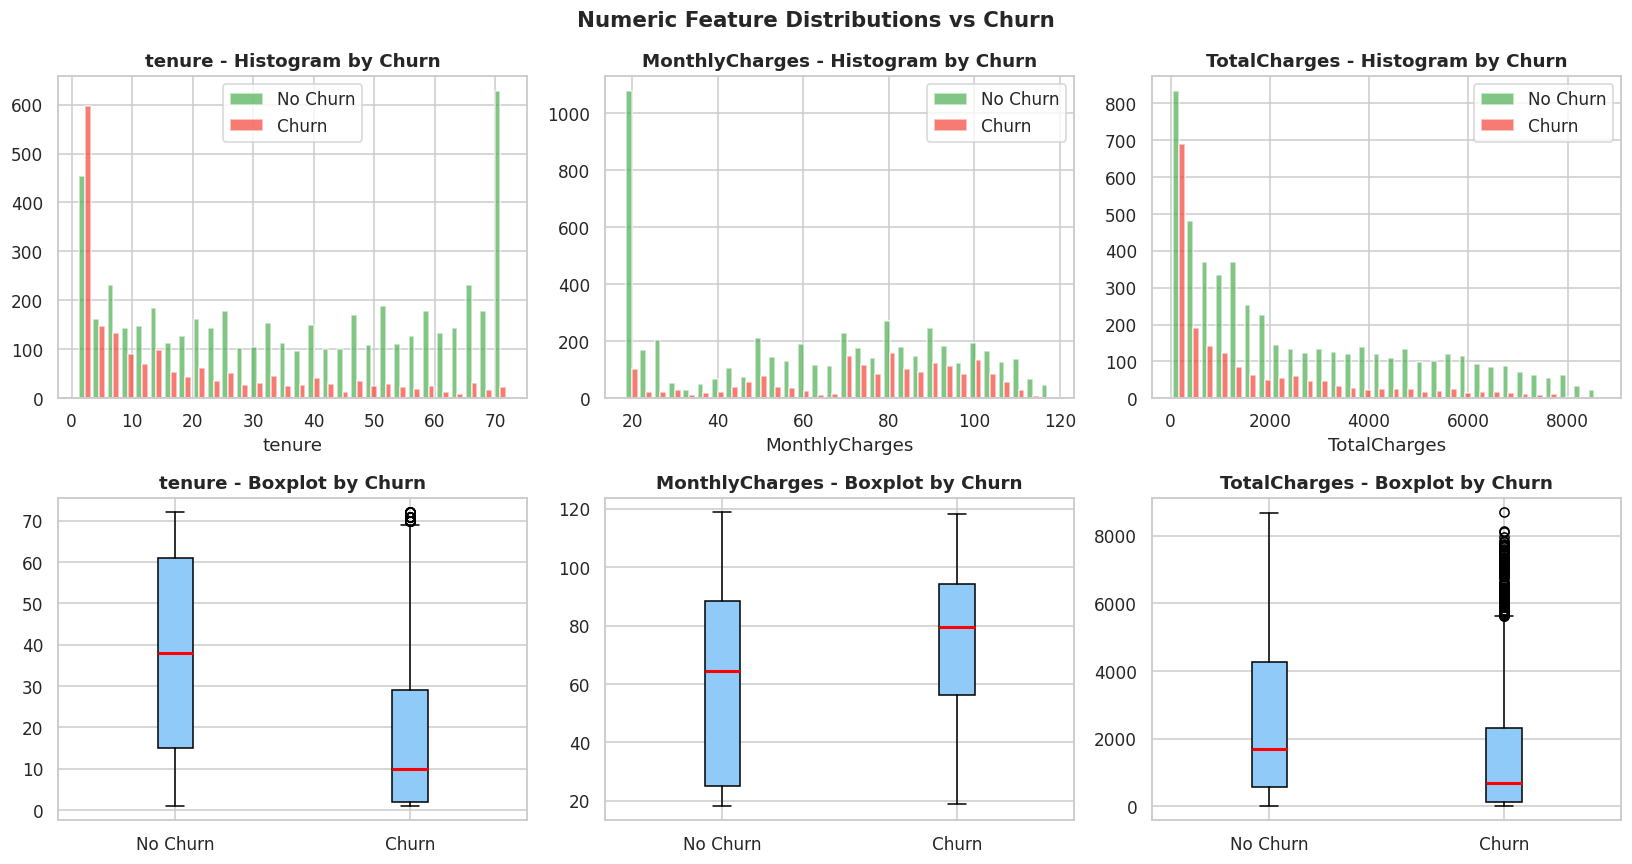


=== Skewness and IQR-based Outlier Summary ===


,Feature,Skew,IQR,Outliers (1.5·IQR),Outlier %
0,tenure,0.238,46.00,0,0.0
1,MonthlyCharges,-0.222,54.27,0,0.0
2,TotalCharges,0.962,3393.29,0,0.0


Interpretation: |skew| < 0.5 ≈ symmetric, 0.5–1 moderately skewed, > 1 highly skewed.


In [13]:
# -------------------------------
# 2) Numeric feature distributions
# -------------------------------
# Focus on high-signal billing/tenure numerical variables.
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Histogram by churn class to compare distribution shifts.
    axes[0, i].hist(
        [eda_df[eda_df['Churn'] == 0][col], eda_df[eda_df['Churn'] == 1][col]],
        bins=30,
        label=['No Churn', 'Churn'],
        color=['#4CAF50', '#F44336'],
        alpha=0.7,
    )
    axes[0, i].set_title(f'{col} - Histogram by Churn', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()

    # Boxplot by churn class to compare medians and spread.
    bp_data = [eda_df[eda_df['Churn'] == 0][col], eda_df[eda_df['Churn'] == 1][col]]
    axes[1, i].boxplot(
        bp_data,
        labels=['No Churn', 'Churn'],
        patch_artist=True,
        boxprops=dict(facecolor='#90CAF9'),
        medianprops=dict(color='red', linewidth=2),
    )
    axes[1, i].set_title(f'{col} - Boxplot by Churn', fontweight='bold')

plt.suptitle('Numeric Feature Distributions vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------
# 2b) Skewness + IQR outlier summary
# -------------------------------
# Quantifies distribution shape and outlier pressure so decisions about scaling
# / transformations later are grounded in data rather than visual inspection.
skew_rows = []
for col in num_cols:
    s = eda_df[col].astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = int(((s < lo) | (s > hi)).sum())
    skew_rows.append({
        'Feature': col,
        'Skew': round(s.skew(), 3),
        'IQR': round(iqr, 2),
        'Outliers (1.5·IQR)': outliers,
        'Outlier %': round(100 * outliers / len(s), 2),
    })

skew_df = pd.DataFrame(skew_rows)
print('\n=== Skewness and IQR-based Outlier Summary ===')
display(skew_df)
print('Interpretation: |skew| < 0.5 ≈ symmetric, 0.5–1 moderately skewed, > 1 highly skewed.')

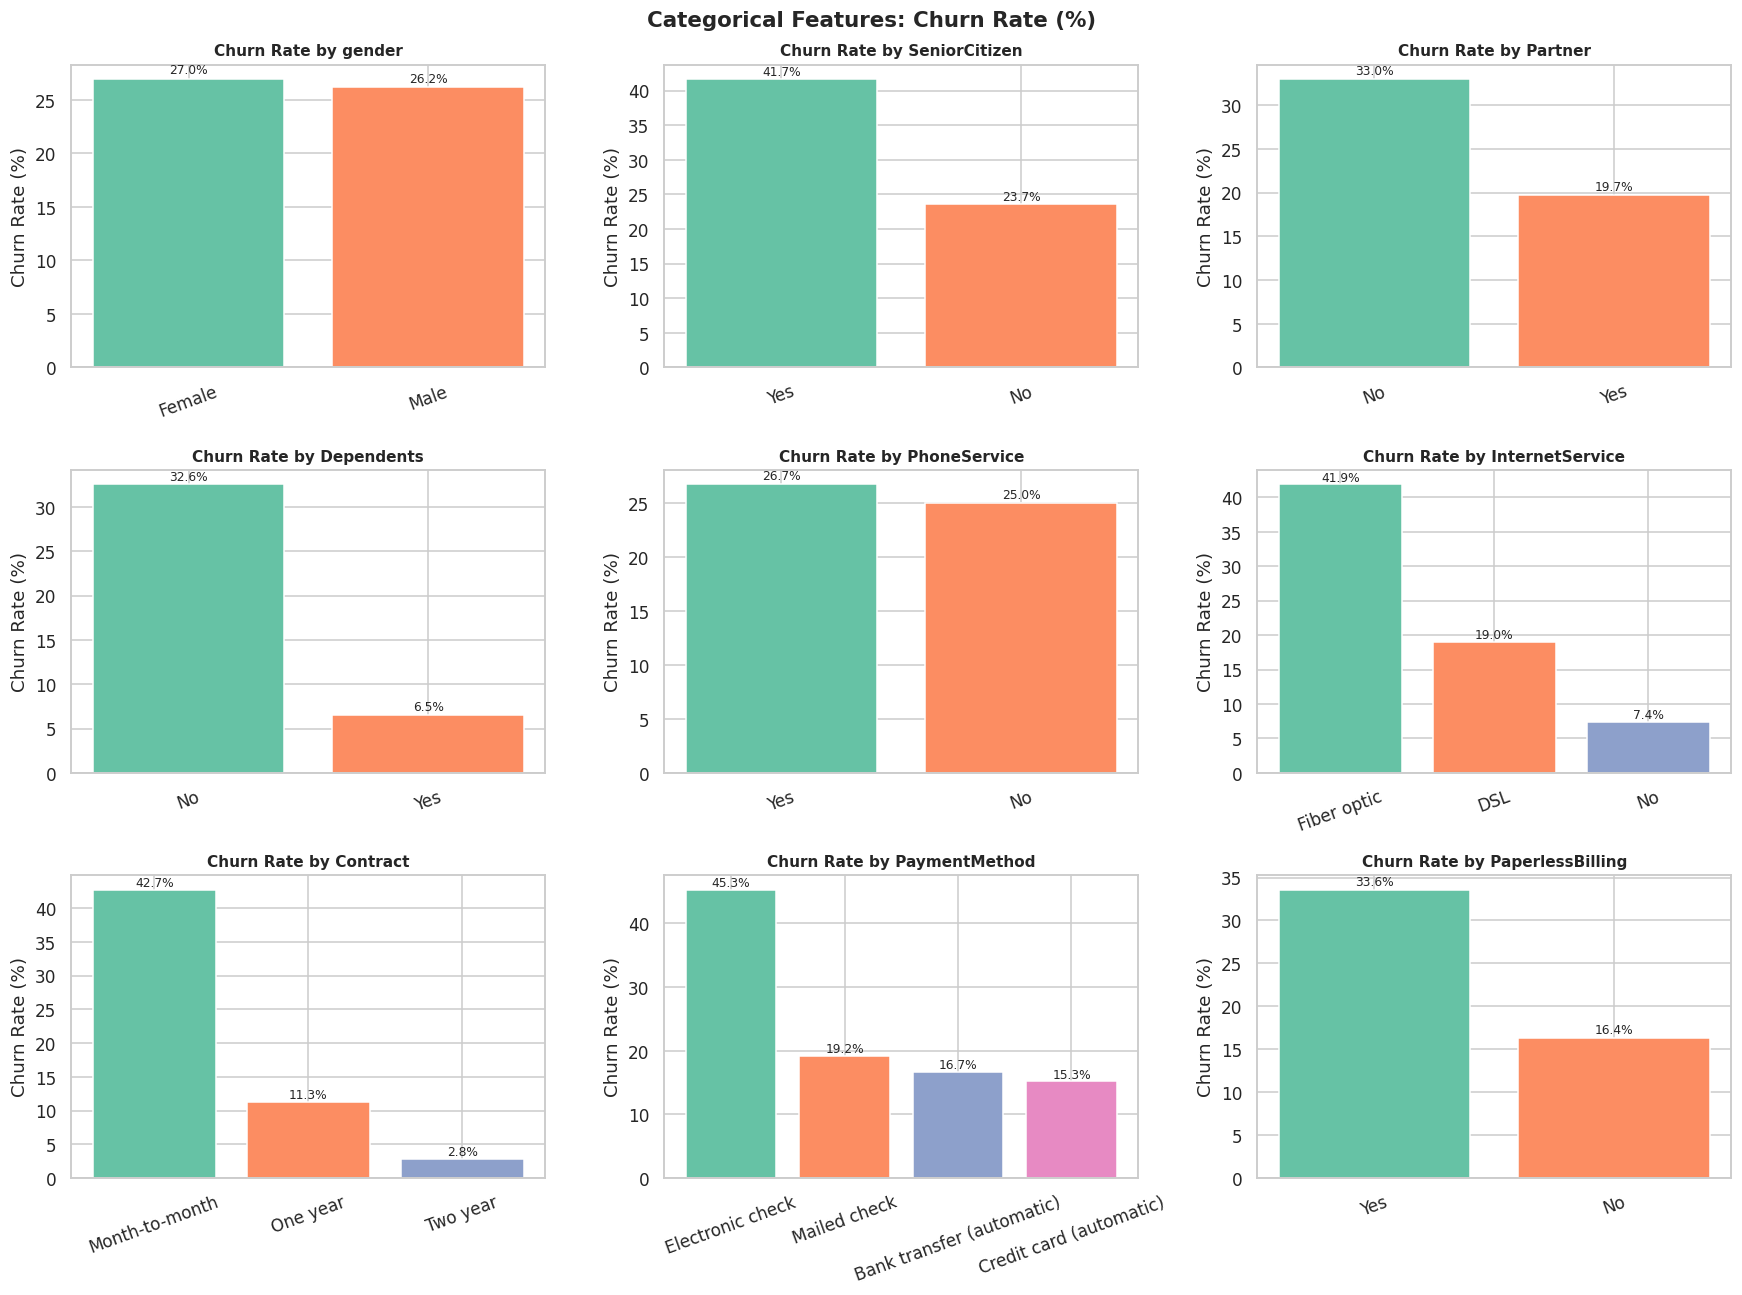

In [14]:
# -------------------------------
# 3) Categorical churn-rate plots
# -------------------------------
# Select key categorical variables for churn-rate comparison.
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'InternetService', 'Contract',
    'PaymentMethod', 'PaperlessBilling',
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Compute churn percentage by category.
    churn_rate = eda_df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100

    # Plot category-level churn rates.
    bars = axes[i].bar(
        churn_rate.index.astype(str),
        churn_rate.values,
        color=sns.color_palette('Set2', len(churn_rate)),
        edgecolor='white',
    )

    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)

    # Add percentage labels on top of bars.
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.5,
            f'{height:.1f}%',
            ha='center',
            fontsize=8,
        )

plt.suptitle('Categorical Features: Churn Rate (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

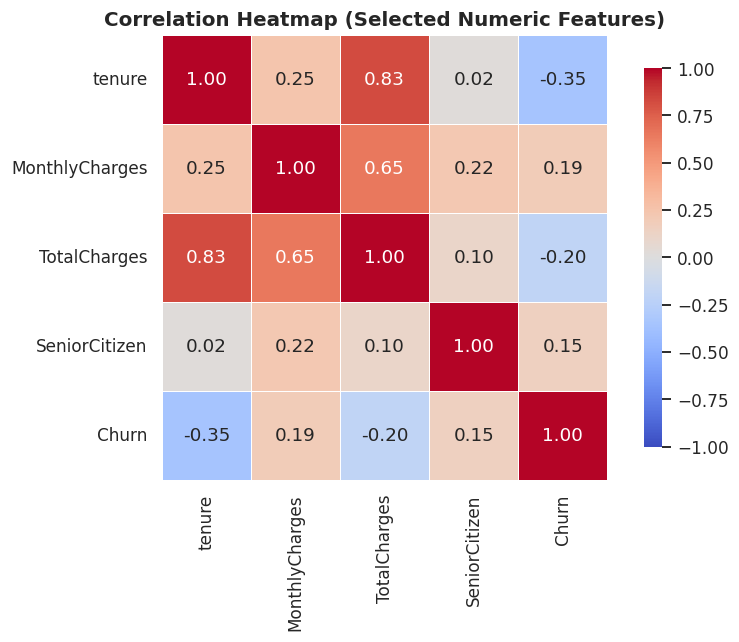

Correlation with Churn:


,corr_with_churn
Churn,1.000000
MonthlyCharges,0.192858
SeniorCitizen,0.150541
TotalCharges,-0.199484
tenure,-0.354049


In [15]:
# -------------------------------
# 4) Correlation heatmap
# -------------------------------
# Build a focused subset for correlation analysis.
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']

# Create a temporary dataframe and normalize mixed-type fields.
corr_df = eda_df[corr_cols].copy()

# Convert SeniorCitizen from Yes/No to 1/0 when stored as text.
if corr_df['SeniorCitizen'].dtype == object:
    corr_df['SeniorCitizen'] = corr_df['SeniorCitizen'].map({'Yes': 1, 'No': 0})

# Force numeric conversion and remove unresolved rows.
corr_df = corr_df.apply(pd.to_numeric, errors='coerce').dropna()

# Compute Pearson correlation matrix.
corr = corr_df.corr(method='pearson')

# Plot a full heatmap with fixed color range for interpretability.
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.85},
)
plt.title('Correlation Heatmap (Selected Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print churn correlations to make the heatmap easier to validate.
print('Correlation with Churn:')
display(corr['Churn'].sort_values(ascending=False).to_frame('corr_with_churn'))

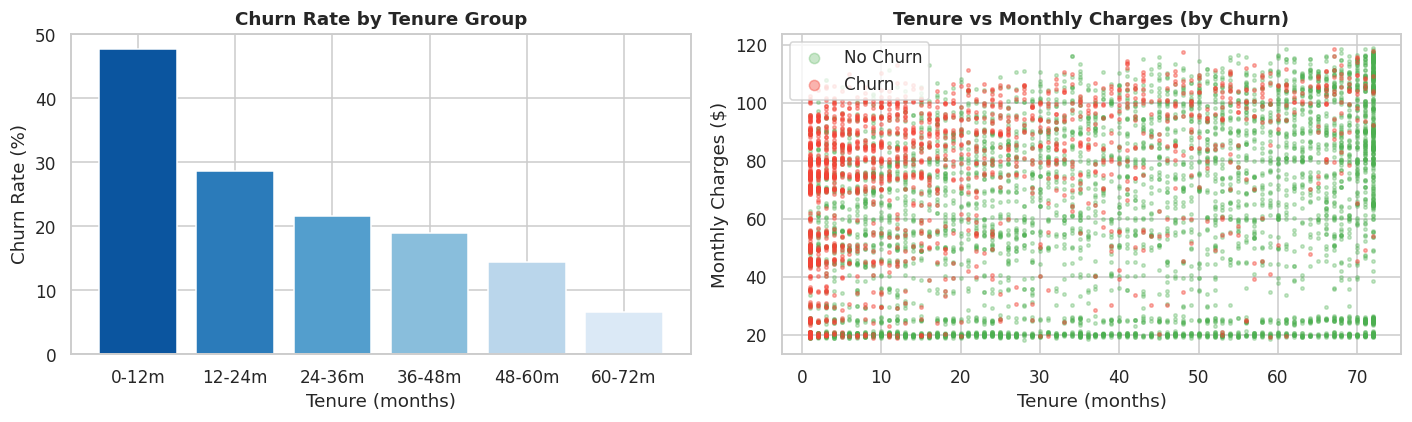

In [16]:
# -------------------------------
# 5) Supporting diagnostic view
# -------------------------------
# Create a tenure-binned view to support churn-behavior interpretation.
eda_df['tenure_bin'] = pd.cut(
    eda_df['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-12m', '12-24m', '24-36m', '36-48m', '48-60m', '60-72m'],
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot churn rate by tenure segment.
churn_by_tenure = eda_df.groupby('tenure_bin')['Churn'].mean() * 100
axes[0].bar(churn_by_tenure.index.astype(str), churn_by_tenure.values,
            color=sns.color_palette('Blues_r', 6))
axes[0].set_title('Churn Rate by Tenure Group', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Tenure (months)')

# Plot tenure vs monthly charges, colored by churn class.
axes[1].scatter(
    eda_df[eda_df['Churn'] == 0]['tenure'],
    eda_df[eda_df['Churn'] == 0]['MonthlyCharges'],
    alpha=0.3, s=5, color='#4CAF50', label='No Churn',
)
axes[1].scatter(
    eda_df[eda_df['Churn'] == 1]['tenure'],
    eda_df[eda_df['Churn'] == 1]['MonthlyCharges'],
    alpha=0.4, s=5, color='#F44336', label='Churn',
)
axes[1].set_title('Tenure vs Monthly Charges (by Churn)', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

# Remove temporary helper column after use.
eda_df.drop(columns=['tenure_bin'], inplace=True)

### 📝 Key EDA Insights

1. **Class imbalance is present**: churners are a minority (about one-quarter), so F1-score is more informative than accuracy.
2. **Tenure is strongly associated with churn**: customers in early tenure periods churn more than long-tenure customers.
3. **Contract type is a major churn driver**: month-to-month contracts have clearly higher churn rates than longer contracts.
4. **Service profile matters**: fiber optic users generally show higher churn risk than other internet-service groups.
5. **Pricing pressure signal exists**: churners tend to carry higher monthly charges, suggesting price sensitivity.

---
## Data Preprocessing

This section prepares the cleaned dataset for modeling using a single
`ColumnTransformer` that is **fitted on the training fold only** to avoid any
leakage into the test set:

- **Stratified train/test split first**, so no statistics are learned from test data.
- **`StandardScaler`** on continuous numeric features only (`tenure`,
  `MonthlyCharges`, `TotalCharges`, `CLTV`). Scaling 0/1 dummies would distort
  interpretation and gives no modeling benefit.
- **`OneHotEncoder(drop='if_binary', handle_unknown='ignore')`** on all
  categorical features. `drop='if_binary'` collapses 2-level fields to a single
  column; `handle_unknown='ignore'` makes the pipeline robust at inference time.
- Remaining already-numeric 0/1 fields (e.g. `SeniorCitizen`) are passed through.

Outputs of this section:
- `X_train`, `X_test`, `y_train`, `y_test`
- `X_train_sc`, `X_test_sc` (numpy arrays; identical to the DataFrames above)
- `feature_names` (final column names after encoding/scaling)
- `preprocessor` (reusable for deployment)

In [17]:
# -------------------------------
# Step 1: Identify feature types for the ColumnTransformer
# -------------------------------
# Start from the cleaned dataset to keep preprocessing aligned with cleaning.
prep_df = df_clean.copy()

# Detect and drop constant object columns (zero predictive signal).
constant_cat_cols = [
    col for col in prep_df.columns
    if prep_df[col].dtype == 'object' and prep_df[col].nunique() <= 1
]
if constant_cat_cols:
    prep_df = prep_df.drop(columns=constant_cat_cols)

target = 'Churn'

# Continuous numeric features -> StandardScaler.
continuous_cols = [
    c for c in ['tenure', 'MonthlyCharges', 'TotalCharges', 'CLTV']
    if c in prep_df.columns
]

# Object categoricals -> OneHotEncoder (drop='if_binary' collapses 2-level cols).
categorical_cols = [c for c in prep_df.columns if prep_df[c].dtype == 'object']

# Already-numeric 0/1 fields (e.g. SeniorCitizen) are passed through untouched;
# scaling them would distort interpretation and gives zero modeling benefit.
passthrough_cols = [
    c for c in prep_df.columns
    if c not in continuous_cols + categorical_cols + [target]
]

print('Dropped constant categorical columns:', constant_cat_cols if constant_cat_cols else 'None')
print(f'Continuous (scaled)       : {continuous_cols}')
print(f'Categorical (one-hot)     : {categorical_cols}')
print(f'Passthrough numeric (0/1) : {passthrough_cols}')

Dropped constant categorical columns: None
Continuous (scaled)       : ['tenure', 'MonthlyCharges', 'TotalCharges', 'CLTV']
Categorical (one-hot)     : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Passthrough numeric (0/1) : []


In [18]:
# -------------------------------
# Step 2: Split X / y and perform a stratified train/test split BEFORE encoding
# -------------------------------
# Splitting first and fitting the encoder only on the training fold prevents
# any test-set information from leaking into categorical encodings or scaler stats.
X_raw = prep_df.drop(columns=[target])
y = prep_df[target].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print(f'X_raw shape  : {X_raw.shape}')
print(f'Training set : {X_train_raw.shape[0]:,} rows ({100 * len(X_train_raw) / len(X_raw):.0f}%)')
print(f'Test set     : {X_test_raw.shape[0]:,} rows ({100 * len(X_test_raw) / len(X_raw):.0f}%)')
print(f'Churn rate (train): {y_train.mean():.3f}')
print(f'Churn rate (test) : {y_test.mean():.3f}')

X_raw shape  : (7032, 20)
Training set : 5,625 rows (80%)
Test set     : 1,407 rows (20%)
Churn rate (train): 0.266
Churn rate (test) : 0.266


In [19]:
# -------------------------------
# Step 3: Build a ColumnTransformer (scale continuous, one-hot encode categoricals)
# -------------------------------
# - StandardScaler is applied only to the truly continuous features. Scaling 0/1
#   dummies would distort interpretation without helping any model.
# - OneHotEncoder(drop='if_binary') collapses 2-level columns to a single column
#   while still one-hot encoding multi-level columns; handle_unknown='ignore'
#   makes the pipeline robust to new categories at inference time.
# - Remainder='passthrough' keeps any already-numeric 0/1 fields untouched.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False),
         categorical_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)

print('ColumnTransformer configured.')
print(f'  Continuous scaled : {len(continuous_cols)} columns')
print(f'  Categorical OHE   : {len(categorical_cols)} columns')
print(f'  Passthrough       : {len(passthrough_cols)} columns')

ColumnTransformer configured.
  Continuous scaled : 4 columns
  Categorical OHE   : 16 columns
  Passthrough       : 0 columns


In [20]:
# -------------------------------
# Step 4: Fit the preprocessor on the training fold, transform both folds
# -------------------------------
# fit_transform on train: scaler learns mean/std from train only, encoder learns
# categories from train only. transform on test applies those learned parameters.
X_train_arr = preprocessor.fit_transform(X_train_raw)
X_test_arr = preprocessor.transform(X_test_raw)

feature_names = list(preprocessor.get_feature_names_out())

print(f'Preprocessed train shape : {X_train_arr.shape}')
print(f'Preprocessed test shape  : {X_test_arr.shape}')
print(f'Final feature count      : {len(feature_names)}')
print('Sample feature names     :', feature_names[:15])

Preprocessed train shape : (5625, 41)
Preprocessed test shape  : (1407, 41)
Final feature count      : 41
Sample feature names     : ['tenure', 'MonthlyCharges', 'TotalCharges', 'CLTV', 'gender_Male', 'SeniorCitizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No']


In [21]:
# -------------------------------
# Step 5: Wrap transformed arrays as DataFrames for downstream interpretability
# -------------------------------
# Downstream cells (feature importance, permutation importance, feature
# selection) need column names. We keep DataFrame copies alongside numpy arrays.
X_train = pd.DataFrame(X_train_arr, columns=feature_names, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_arr, columns=feature_names, index=X_test_raw.index)

# Full encoded design matrix (only used for reference / feature-importance naming).
X = pd.concat([X_train, X_test]).sort_index()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
display(X_train.head(3))

X_train : (5625, 41)
X_test  : (1407, 41)


,tenure,MonthlyCharges,TotalCharges,CLTV,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2907,1.321816,0.981556,1.659900,0.164463,1.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7014,-0.267410,-0.971546,-0.562252,-1.415108,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4346,1.444064,0.837066,1.756104,-0.264870,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [22]:
# -------------------------------
# Step 6: Expose scaled design matrices for scale-sensitive models (LR, ANN)
# -------------------------------
# The ColumnTransformer already scales the continuous block, so the preprocessed
# arrays are ready for Logistic Regression and the ANN as-is. Tree-based models
# (Random Forest, XGBoost) are scale-invariant and also accept these arrays,
# which keeps every model on a single, consistent feature space.
X_train_sc = X_train_arr
X_test_sc = X_test_arr

print('Preprocessing complete (ColumnTransformer: scale + one-hot + passthrough).')
print(f'Scaled train shape: {X_train_sc.shape}')
print(f'Scaled test shape : {X_test_sc.shape}')

Preprocessing complete (ColumnTransformer: scale + one-hot + passthrough).
Scaled train shape: (5625, 41)
Scaled test shape : (1407, 41)


---
## Model Building (ML Baselines First)

In this section, we train three baseline machine learning classifiers in order:
1. Logistic Regression
2. Random Forest
3. XGBoost

For each model, we generate:
- Class predictions (`predict`)
- Churn probabilities (`predict_proba`) for ROC-AUC and threshold analysis



In [23]:
# Central log of training + inference time for the ML-vs-DL comparison.
timing_log = {}

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED,
)

t0 = perf_counter()
lr_model.fit(X_train_sc, y_train)
lr_fit_time = perf_counter() - t0

t0 = perf_counter()
lr_pred = lr_model.predict(X_test_sc)
lr_proba = lr_model.predict_proba(X_test_sc)[:, 1]
lr_pred_time = perf_counter() - t0

timing_log['Logistic Regression'] = (lr_fit_time, lr_pred_time)

print('=== Logistic Regression ===')
print(f'Accuracy    : {accuracy_score(y_test, lr_pred):.4f}')
print(f'F1 Score    : {f1_score(y_test, lr_pred):.4f}')
print(f'ROC-AUC     : {roc_auc_score(y_test, lr_proba):.4f}')
print(f'Train time  : {lr_fit_time:.3f}s  |  Predict time: {lr_pred_time:.4f}s')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['No Churn', 'Churn']))

=== Logistic Regression ===
Accuracy    : 0.7299
F1 Score    : 0.6082
ROC-AUC     : 0.8426
Train time  : 0.019s  |  Predict time: 0.0005s

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [24]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

t0 = perf_counter()
rf_model.fit(X_train, y_train)
rf_fit_time = perf_counter() - t0

t0 = perf_counter()
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred_time = perf_counter() - t0

timing_log['Random Forest'] = (rf_fit_time, rf_pred_time)

print('=== Random Forest ===')
print(f'Accuracy    : {accuracy_score(y_test, rf_pred):.4f}')
print(f'F1 Score    : {f1_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC     : {roc_auc_score(y_test, rf_proba):.4f}')
print(f'Train time  : {rf_fit_time:.3f}s  |  Predict time: {rf_pred_time:.4f}s')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['No Churn', 'Churn']))

=== Random Forest ===
Accuracy    : 0.7918
F1 Score    : 0.5581
ROC-AUC     : 0.8304
Train time  : 0.344s  |  Predict time: 0.0677s

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



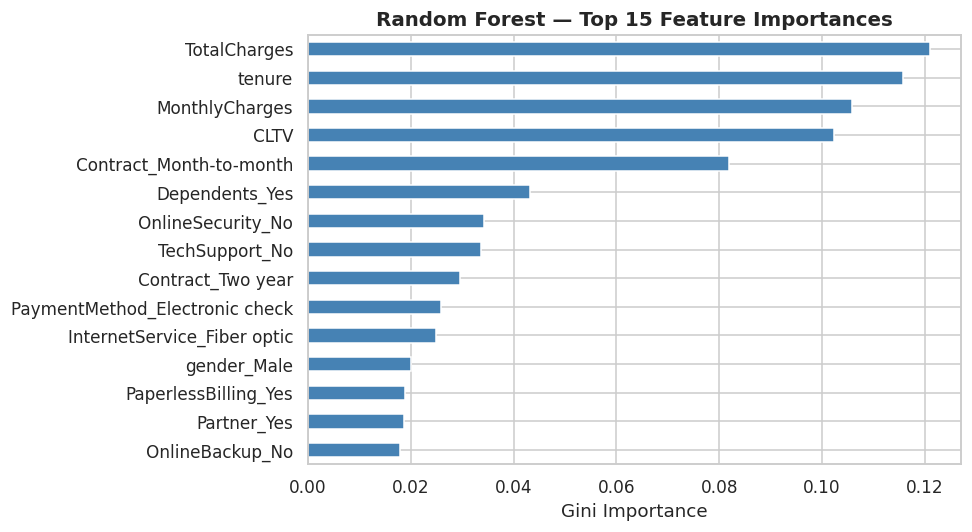

In [25]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15)

plt.figure(figsize=(9, 5))
top15.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

In [26]:
# XGBoost
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
)

t0 = perf_counter()
xgb_model.fit(X_train, y_train)
xgb_fit_time = perf_counter() - t0

t0 = perf_counter()
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred_time = perf_counter() - t0

timing_log['XGBoost'] = (xgb_fit_time, xgb_pred_time)

print('=== XGBoost ===')
print(f'Accuracy    : {accuracy_score(y_test, xgb_pred):.4f}')
print(f'F1 Score    : {f1_score(y_test, xgb_pred):.4f}')
print(f'ROC-AUC     : {roc_auc_score(y_test, xgb_proba):.4f}')
print(f'Train time  : {xgb_fit_time:.3f}s  |  Predict time: {xgb_pred_time:.4f}s')
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['No Churn', 'Churn']))

=== XGBoost ===
Accuracy    : 0.7434
F1 Score    : 0.6243
ROC-AUC     : 0.8424
Train time  : 0.564s  |  Predict time: 0.0072s

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81      1033
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



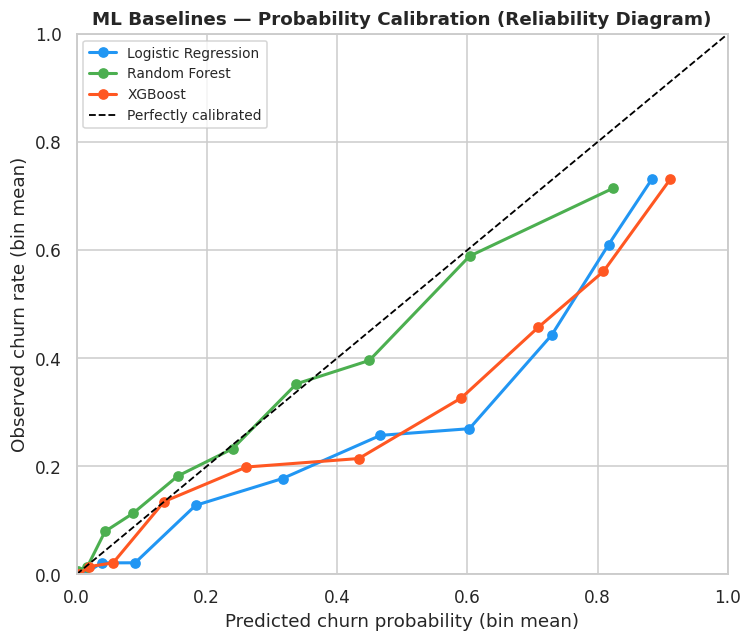

Baseline probability table shape: (1407, 3)


In [27]:
# -------------------------------
# Baseline probability calibration (reliability diagram)
# -------------------------------
# A well-calibrated classifier produces probabilities that match observed rates.
# This matters for business use: "predicted churn probability of 0.7" should
# actually correspond to ~70% observed churn in that bin. The diagonal is the
# ideal; curves above it are under-confident, below it are over-confident.
ml_proba_df = pd.DataFrame({
    'Logistic Regression': lr_proba,
    'Random Forest': rf_proba,
    'XGBoost': xgb_proba,
})

fig, ax = plt.subplots(figsize=(7, 6))
for name, color in zip(ml_proba_df.columns, ['#2196F3', '#4CAF50', '#FF5722']):
    prob_true, prob_pred = calibration_curve(y_test, ml_proba_df[name], n_bins=10, strategy='quantile')
    ax.plot(prob_pred, prob_true, marker='o', lw=2, color=color, label=name)

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfectly calibrated')
ax.set_xlabel('Predicted churn probability (bin mean)')
ax.set_ylabel('Observed churn rate (bin mean)')
ax.set_title('ML Baselines — Probability Calibration (Reliability Diagram)', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print('Baseline probability table shape:', ml_proba_df.shape)

---
## Model Evaluation (Consistent and Fair)

This section evaluates all ML baseline models using the same protocol:
- Accuracy, F1-score, and ROC-AUC
- Classification report
- Confusion matrix
- ROC curve
- One unified comparison table

In [28]:
# -------------------------------
# Step 1: Unified metric calculation + classification reports
# -------------------------------
# Store predictions/probabilities for consistent downstream evaluation.
models_info = [
    ('Logistic Regression', lr_pred, lr_proba),
    ('Random Forest', rf_pred, rf_proba),
    ('XGBoost', xgb_pred, xgb_proba),
]

# Compute a single comparison table with identical metrics for all models.
# PR-AUC (average_precision_score) is included alongside ROC-AUC because it is
# more sensitive than ROC-AUC on imbalanced classification problems like churn.
rows = []
for name, pred, proba in models_info:
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
    })

results_ml = pd.DataFrame(rows).sort_values('F1 Score', ascending=False).reset_index(drop=True)

# Print classification report for each model using the same test set.
for name, pred, _ in models_info:
    print(f'\n=== {name} — Classification Report ===')
    print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))


=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.79      1033
       Churn       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1033
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.81      1033
       Churn       0.51      0.80      0.62       374

    accuracy                           0.

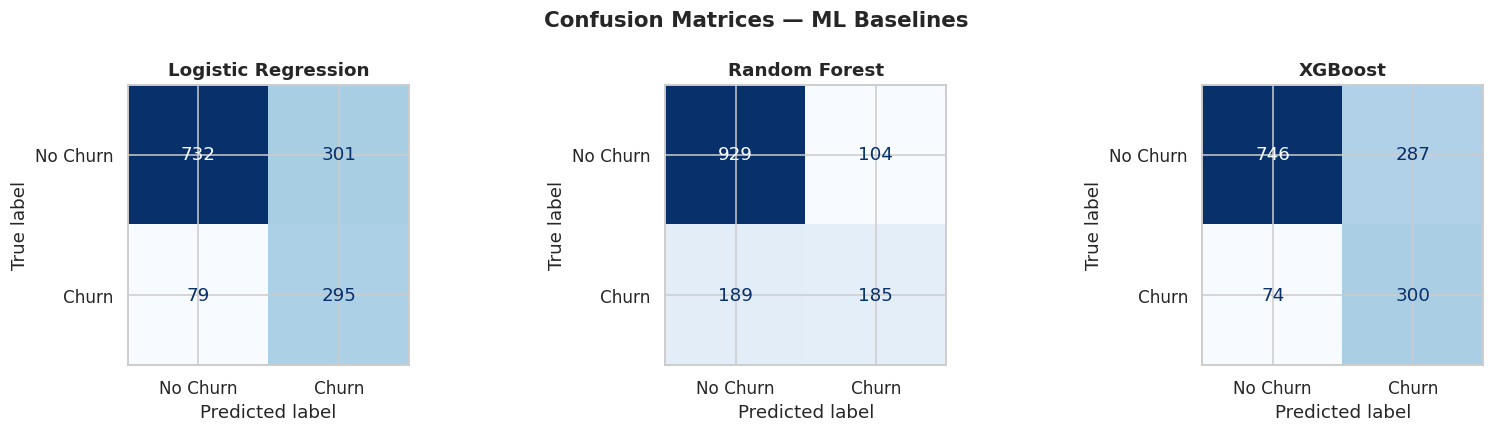

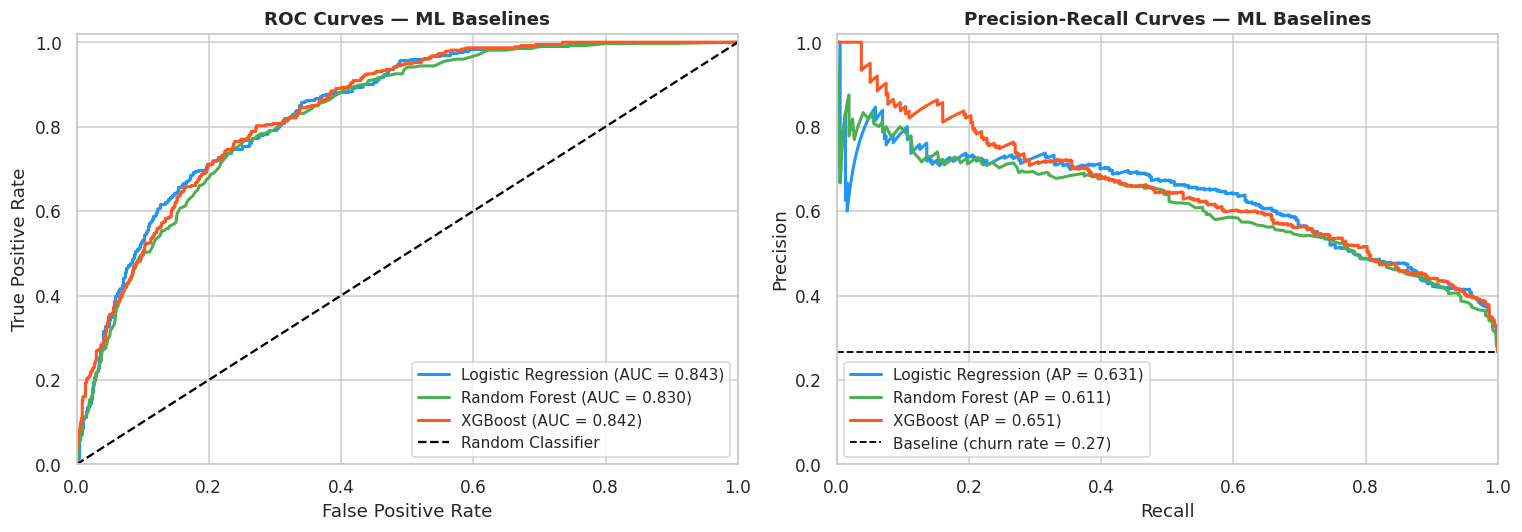

In [29]:
# -------------------------------
# Step 2: Confusion matrices + ROC curves + Precision-Recall curves
# -------------------------------
# Confusion matrices for all baseline models.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred, _) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
        ax=ax, cmap='Blues', colorbar=False,
    )
    ax.set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices — ML Baselines', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC + Precision-Recall curves side by side. PR curves are shown alongside ROC
# because PR-AUC is a stronger discriminator between models on imbalanced data:
# it focuses on the positive (churn) class instead of the negative majority.
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']

for (name, _, proba), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax_pr.plot(recall, precision, color=color, lw=2,
               label=f'{name} (AP = {ap:.3f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.02)
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — ML Baselines', fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)

# Baseline on the PR plot is the positive class prevalence (churn rate).
baseline = y_test.mean()
ax_pr.axhline(baseline, color='k', linestyle='--', lw=1.2,
              label=f'Baseline (churn rate = {baseline:.2f})')
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.02)
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves — ML Baselines', fontweight='bold')
ax_pr.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()


=== ML Baseline Comparison Table ===


,Model,Accuracy,F1 Score,ROC-AUC,PR-AUC
0,XGBoost,0.7434,0.6243,0.8424,0.6513
1,Logistic Regression,0.7299,0.6082,0.8426,0.6310
2,Random Forest,0.7918,0.5581,0.8304,0.6112


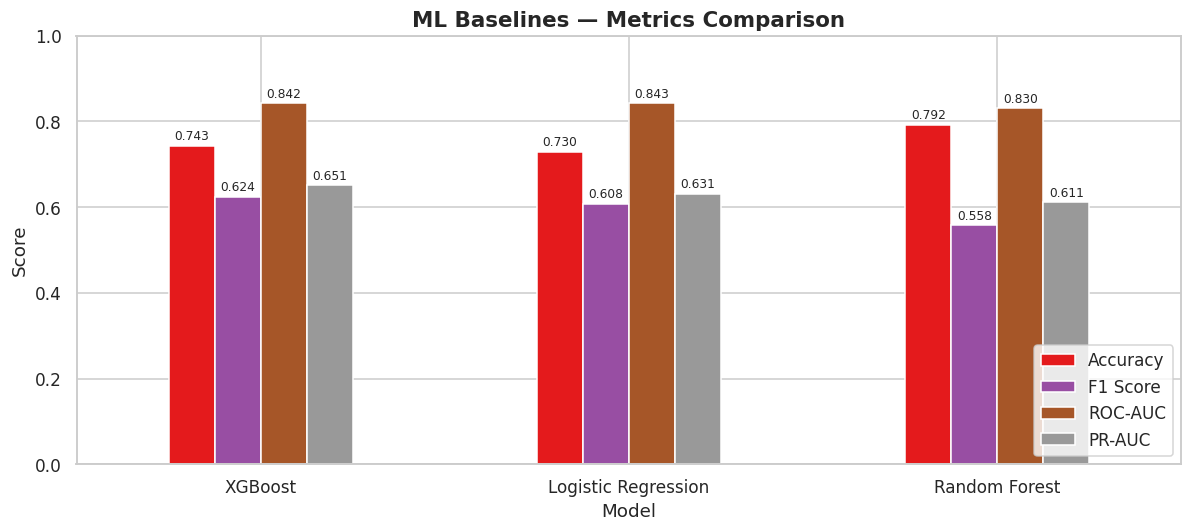


=== Stratified 5-fold CV (on training fold only) ===


,Model,F1 (CV mean),F1 (CV std),ROC-AUC (CV mean),ROC-AUC (CV std)
0,Logistic Regression,0.6459,0.0144,0.8594,0.0087
1,XGBoost,0.6437,0.0090,0.8594,0.0061
2,Random Forest,0.5771,0.0203,0.8480,0.0077


In [30]:
# -------------------------------
# Step 3: One comparison table for all ML models
# -------------------------------
print('\n=== ML Baseline Comparison Table ===')
display(results_ml.round(4))

# Visual summary from the same unified table (Accuracy / F1 / ROC-AUC / PR-AUC).
plot_df = results_ml.set_index('Model')[['Accuracy', 'F1 Score', 'ROC-AUC', 'PR-AUC']]
ax = plot_df.plot(kind='bar', figsize=(11, 5), colormap='Set1', edgecolor='white', rot=0)
ax.set_title('ML Baselines — Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

# -------------------------------
# Step 4: Stratified 5-fold cross-validation (more stable than a single split)
# -------------------------------
# The hold-out split gives one point estimate; CV gives a distribution, which is
# useful evidence for the ML-vs-DL comparison in the conclusion.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
}

cv_rows = []
for name, model in cv_models.items():
    f1_cv = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)
    auc_cv = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'F1 (CV mean)': f1_cv.mean(),
        'F1 (CV std)': f1_cv.std(),
        'ROC-AUC (CV mean)': auc_cv.mean(),
        'ROC-AUC (CV std)': auc_cv.std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values('F1 (CV mean)', ascending=False).reset_index(drop=True)
print('\n=== Stratified 5-fold CV (on training fold only) ===')
display(cv_results.round(4))

---
## Model Optimization

This section includes:
- Hyperparameter tuning using `RandomizedSearchCV`
- Optional feature-selection experiment
- Re-evaluation of tuned models using the same metrics:
  - Accuracy
  - F1 Score
  - ROC-AUC
  - Classification report

In [31]:
# RandomizedSearchCV on Random Forest

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1,
    random_state=SEED,
)

rf_random.fit(X_train, y_train)
print(f'\nBest CV F1 Score : {rf_random.best_score_:.4f}')
print(f'Best Parameters    : {rf_random.best_params_}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best CV F1 Score : 0.5987
Best Parameters    : {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}


In [32]:
# Re-evaluate tuned Random Forest (same metrics as baselines) and time it on the
# full training fold so the timing comparison is apples-to-apples.
best_rf = RandomForestClassifier(**rf_random.best_params_, random_state=SEED, n_jobs=-1)

t0 = perf_counter()
best_rf.fit(X_train, y_train)
best_rf_fit_time = perf_counter() - t0

t0 = perf_counter()
best_rf_pred = best_rf.predict(X_test)
best_rf_proba = best_rf.predict_proba(X_test)[:, 1]
best_rf_pred_time = perf_counter() - t0

timing_log['Random Forest (tuned)'] = (best_rf_fit_time, best_rf_pred_time)

print('=== Tuned Random Forest ===')
print(f'Accuracy    : {accuracy_score(y_test, best_rf_pred):.4f}')
print(f'F1 Score    : {f1_score(y_test, best_rf_pred):.4f}')
print(f'ROC-AUC     : {roc_auc_score(y_test, best_rf_proba):.4f}')
print(f'PR-AUC      : {average_precision_score(y_test, best_rf_proba):.4f}')
print(f'Train time  : {best_rf_fit_time:.3f}s  |  Predict time: {best_rf_pred_time:.4f}s')
print('\nClassification Report:')
print(classification_report(y_test, best_rf_pred, target_names=['No Churn', 'Churn']))

=== Tuned Random Forest ===
Accuracy    : 0.7996
F1 Score    : 0.5889
ROC-AUC     : 0.8424
PR-AUC      : 0.6514
Train time  : 0.494s  |  Predict time: 0.1116s

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1033
       Churn       0.65      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [33]:
# RandomizedSearchCV on XGBoost (best ML model)
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
}

xgb_base = XGBClassifier(
    scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
)

rs = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=25,
    scoring='f1',
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)
rs.fit(X_train, y_train)

print(f'\nBest CV F1 Score : {rs.best_score_:.4f}')
print(f'Best Parameters    : {rs.best_params_}')


Best CV F1 Score : 0.6506
Best Parameters    : {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [34]:
# Re-evaluate tuned XGBoost (same metrics as baselines). We re-fit on the full
# training fold so timing is directly comparable to the other tuned models.
best_xgb = XGBClassifier(
    **rs.best_params_,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='logloss',
    random_state=SEED,
    n_jobs=-1,
)

t0 = perf_counter()
best_xgb.fit(X_train, y_train)
best_xgb_fit_time = perf_counter() - t0

t0 = perf_counter()
best_xgb_pred = best_xgb.predict(X_test)
best_xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
best_xgb_pred_time = perf_counter() - t0

timing_log['XGBoost (tuned)'] = (best_xgb_fit_time, best_xgb_pred_time)

print('=== Tuned XGBoost ===')
print(f'Accuracy    : {accuracy_score(y_test, best_xgb_pred):.4f}')
print(f'F1 Score    : {f1_score(y_test, best_xgb_pred):.4f}')
print(f'ROC-AUC     : {roc_auc_score(y_test, best_xgb_proba):.4f}')
print(f'PR-AUC      : {average_precision_score(y_test, best_xgb_proba):.4f}')
print(f'Train time  : {best_xgb_fit_time:.3f}s  |  Predict time: {best_xgb_pred_time:.4f}s')
print('\nClassification Report:')
print(classification_report(y_test, best_xgb_pred, target_names=['No Churn', 'Churn']))

=== Tuned XGBoost ===
Accuracy    : 0.7484
F1 Score    : 0.6282
ROC-AUC     : 0.8445
PR-AUC      : 0.6544
Train time  : 0.853s  |  Predict time: 0.0073s

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1033
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.81      0.75      0.76      1407



In [35]:
# Feature-selection experiment (using tuned XGBoost importances).
# We pick features with >0.5% importance, then *re-tune* XGBoost on the reduced
# feature set so the comparison is fair (the tuned hyper-parameters for the full
# feature space may not be optimal on the reduced one).
importances_xgb = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
selected_features = importances_xgb[importances_xgb > 0.005].index.tolist()

print(f'Features before selection: {X_train.shape[1]}')
print(f'Features after selection : {len(selected_features)}')
print(f'Features dropped         : {X_train.shape[1] - len(selected_features)}')

X_train_fs = X_train[selected_features]
X_test_fs = X_test[selected_features]

# Re-tune XGBoost on the reduced feature set (smaller search to keep it fast).
fs_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=neg_pos_ratio,
        eval_metric='logloss',
        random_state=SEED,
        n_jobs=-1,
    ),
    param_dist,
    n_iter=15,
    scoring='f1',
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)
fs_search.fit(X_train_fs, y_train)
best_xgb_fs = fs_search.best_estimator_

t0 = perf_counter()
best_xgb_fs.fit(X_train_fs, y_train)
fs_fit_time = perf_counter() - t0

t0 = perf_counter()
fs_pred = best_xgb_fs.predict(X_test_fs)
fs_proba = best_xgb_fs.predict_proba(X_test_fs)[:, 1]
fs_pred_time = perf_counter() - t0

timing_log['XGBoost (tuned + FS)'] = (fs_fit_time, fs_pred_time)

print(f'\nBest params (FS) : {fs_search.best_params_}')
print('\n=== Tuned XGBoost + Feature Selection ===')
print(f'Accuracy    : {accuracy_score(y_test, fs_pred):.4f}')
print(f'F1 Score    : {f1_score(y_test, fs_pred):.4f}')
print(f'ROC-AUC     : {roc_auc_score(y_test, fs_proba):.4f}')
print(f'PR-AUC      : {average_precision_score(y_test, fs_proba):.4f}')
print(f'Train time  : {fs_fit_time:.3f}s  |  Predict time: {fs_pred_time:.4f}s')
print('\nClassification Report:')
print(classification_report(y_test, fs_pred, target_names=['No Churn', 'Churn']))

Features before selection: 41
Features after selection : 35
Features dropped         : 6

Best params (FS) : {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

=== Tuned XGBoost + Feature Selection ===
Accuracy    : 0.7491
F1 Score    : 0.6304
ROC-AUC     : 0.8446
PR-AUC      : 0.6533
Train time  : 0.975s  |  Predict time: 0.0107s

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1033
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.77      0.72      1407
weighted avg       0.81      0.75      0.76      1407



                       Accuracy  F1 Score  ROC-AUC  PR-AUC  Train (s)  Predict (s)
Model                                                                             
XGBoost (tuned + FS)     0.7491    0.6304   0.8446  0.6533     0.9753       0.0107
XGBoost (tuned)          0.7484    0.6282   0.8445  0.6544     0.8526       0.0073
XGBoost                  0.7434    0.6243   0.8424  0.6513     0.5635       0.0072
Logistic Regression      0.7299    0.6082   0.8426  0.6310     0.0186       0.0005
Random Forest (tuned)    0.7996    0.5889   0.8424  0.6514     0.4943       0.1116
Random Forest            0.7918    0.5581   0.8304  0.6112     0.3442       0.0677


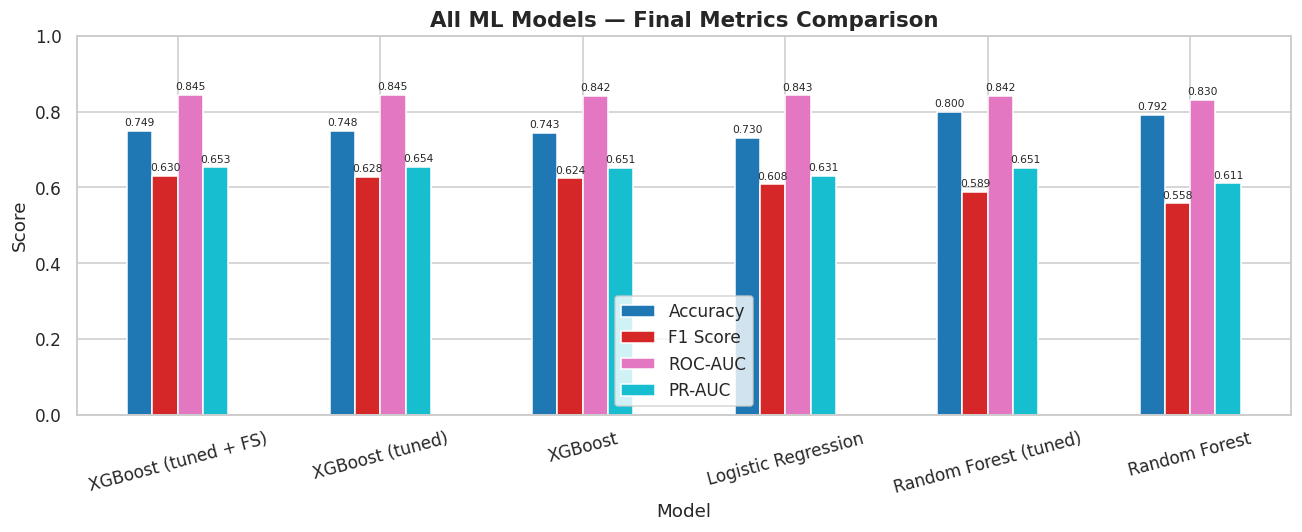

In [36]:
# Final ML comparison table (baseline + tuned + feature-selection variants).
# Includes PR-AUC (key for imbalanced churn) and measured training/inference
# time, which is the empirical evidence for "when ML beats DL on tabular data".
ml_rows = [
    ('Logistic Regression', lr_pred, lr_proba),
    ('Random Forest', rf_pred, rf_proba),
    ('Random Forest (tuned)', best_rf_pred, best_rf_proba),
    ('XGBoost', xgb_pred, xgb_proba),
    ('XGBoost (tuned)', best_xgb_pred, best_xgb_proba),
    ('XGBoost (tuned + FS)', fs_pred, fs_proba),
]

final_ml = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
        'Train (s)': timing_log.get(name, (np.nan, np.nan))[0],
        'Predict (s)': timing_log.get(name, (np.nan, np.nan))[1],
    }
    for name, pred, proba in ml_rows
]).sort_values('F1 Score', ascending=False).set_index('Model')

print(final_ml.round(4).to_string())

metric_cols = ['Accuracy', 'F1 Score', 'ROC-AUC', 'PR-AUC']
ax = final_ml[metric_cols].plot(kind='bar', figsize=(12, 5), colormap='tab10',
                                edgecolor='white', rot=15)
ax.set_title('All ML Models — Final Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.show()

---
## Model Building — Deep Learning (ANN)

### Why an ANN for tabular churn?
We compare a feed-forward neural network to classical ML models. For structured telecom data, ANNs can learn **non-linear interactions** between features (for example contract type and monthly charges) without hand-crafted feature crosses. This satisfies the project requirement for a **deep learning (ANN)** baseline alongside tree and linear models.

### Architecture (and why this design)
- **Input layer**: one unit per scaled feature (same feature space as ML models, but with learned non-linear transforms).
- **Hidden stack (128 → 64 → 32, ReLU, He initialization)**: enough capacity to capture interaction effects without an excessively wide network on a dataset of this size.
- **BatchNormalization + Dropout**: stabilize training and limit overfitting on tabular data.
- **Output: single sigmoid unit**: outputs churn probability in the range [0, 1].

### Training strategy
- **Loss**: `binary_crossentropy` (standard for probabilistic binary classification).
- **Optimizer**: Adam with a moderate learning rate for stable updates.
- **Class weights**: `compute_class_weight('balanced')` so the minority churn class is not ignored (aligned with F1-focused evaluation).
- **Early stopping**: monitor `val_auc`, restore best weights when validation AUC stops improving.
- **ReduceLROnPlateau**: reduce learning rate when validation loss plateaus.
- **Validation split**: 15% of the training fold used only for monitoring (not the held-out test set).

### Evaluation (consistent with ML)
We report the **same metrics** as the ML baselines: **Accuracy**, **F1**, **ROC-AUC**, plus **classification report** and **confusion matrix**, all on the same `y_test`.

### Threshold tuning (Youden’s J)
The ANN outputs **probabilities**. A fixed 0.5 cutoff is often suboptimal when classes are imbalanced. We compute **Youden’s J** (`TPR − FPR`) on the ROC curve and select the threshold that maximizes it, then build `ann_pred` from that threshold. ROC-AUC still uses the raw probabilities.

In [37]:
# Build ANN
def build_ann(input_dim, learning_rate=0.001):
    """
    ANN Architecture:
      Input  → Dense(128, relu) → Dropout(0.3)
             → Dense(64,  relu) → Dropout(0.3)
             → Dense(32,  relu) → Dropout(0.2)
             → Dense(1,   sigmoid)   ← binary output
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu',
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu',
                     kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu',
                     kernel_initializer='he_normal'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model

ann = build_ann(X_train_sc.shape[1])
ann.summary()

W0000 00:00:1776401947.109497   13932 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [38]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train.values)
class_weights = {0: cw[0], 1: cw[1]}
print(f'Class weights: {class_weights}')

Class weights: {0: np.float64(0.6809927360774818), 1: np.float64(1.8812709030100334)}


In [39]:
# Train ANN
tf.random.set_seed(SEED)
np.random.seed(SEED)

early_stop = callbacks.EarlyStopping(
    monitor='val_auc', patience=15, restore_best_weights=True, mode='max',
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=0,
)

t0 = perf_counter()
history = ann.fit(
    X_train_sc, y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)
ann_fit_time = perf_counter() - t0
print(f'\nANN training time: {ann_fit_time:.2f}s over {len(history.history["loss"])} epochs')

Epoch 1/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6494 - auc: 0.7307 - loss: 0.6717 - precision: 0.4147 - recall: 0.7494 - val_accuracy: 0.7334 - val_auc: 0.8341 - val_loss: 0.5316 - val_precision: 0.4848 - val_recall: 0.8224 - learning_rate: 0.0010
Epoch 2/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7201 - auc: 0.8015 - loss: 0.5625 - precision: 0.4860 - recall: 0.7728 - val_accuracy: 0.7630 - val_auc: 0.8532 - val_loss: 0.4940 - val_precision: 0.5207 - val_recall: 0.8224 - learning_rate: 0.0010
Epoch 3/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7218 - auc: 0.8083 - loss: 0.5442 - precision: 0.4880 - recall: 0.7760 - val_accuracy: 0.7654 - val_auc: 0.8548 - val_loss: 0.4723 - val_precision: 0.5238 - val_recall: 0.8224 - learning_rate: 0.0010
Epoch 4/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7302 - auc: 0.8289 - loss: 0.5128 - precision: 0.4978 - recall: 0.7923 - val_accuracy: 0.7547 - val_auc: 0.8592 - val_loss: 0.4882 - val_pr

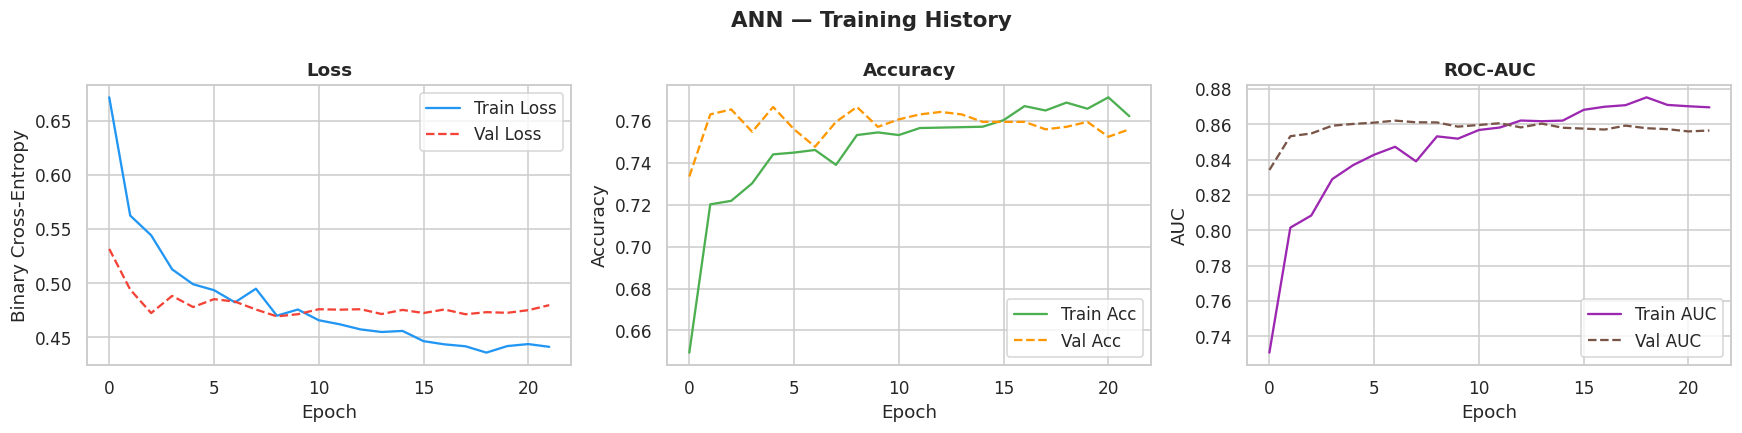

In [40]:
# ── 11.4  Training History Plots ──────────────────────────────────────────────
hist = history.history

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(hist['loss'],     label='Train Loss', color='#2196F3')
axes[0].plot(hist['val_loss'], label='Val Loss',   color='#F44336', linestyle='--')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend()
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Cross-Entropy')

# Accuracy
axes[1].plot(hist['accuracy'],     label='Train Acc', color='#4CAF50')
axes[1].plot(hist['val_accuracy'], label='Val Acc',   color='#FF9800', linestyle='--')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

# AUC
axes[2].plot(hist['auc'],     label='Train AUC', color='#9C27B0')
axes[2].plot(hist['val_auc'], label='Val AUC',   color='#795548', linestyle='--')
axes[2].set_title('ROC-AUC', fontweight='bold'); axes[2].legend()
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')

plt.suptitle('ANN — Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
# Evaluate ANN (same metrics as ML models)
t0 = perf_counter()
ann_proba = ann.predict(X_test_sc, verbose=0).flatten()
ann_pred_time = perf_counter() - t0

# ROC-AUC / PR-AUC use probabilities only (threshold-independent).
ann_auc = roc_auc_score(y_test, ann_proba)
ann_ap = average_precision_score(y_test, ann_proba)

# Reference: default 0.5 threshold (often suboptimal under class imbalance).
pred_default = (ann_proba >= 0.5).astype(int)
print('=== ANN — default threshold 0.5 (reference) ===')
print(f'Accuracy : {accuracy_score(y_test, pred_default):.4f}')
print(f'F1 Score : {f1_score(y_test, pred_default):.4f}')
print(f'ROC-AUC  : {ann_auc:.4f}')
print(f'PR-AUC   : {ann_ap:.4f}')

# Optimal threshold using Youden's J (maximize TPR - FPR).
fpr_ann, tpr_ann, thresholds = roc_curve(y_test, ann_proba)
j_scores = tpr_ann - fpr_ann
best_thresh = thresholds[np.argmax(j_scores)]
print(f'\nOptimal threshold (Youden): {best_thresh:.3f}')

ann_pred = (ann_proba >= best_thresh).astype(int)

timing_log['ANN (Deep Learning)'] = (ann_fit_time, ann_pred_time)

print('\n=== ANN — final (Youden threshold; reported like ML baselines) ===')
print(f'Accuracy    : {accuracy_score(y_test, ann_pred):.4f}')
print(f'F1 Score    : {f1_score(y_test, ann_pred):.4f}')
print(f'ROC-AUC     : {ann_auc:.4f}')
print(f'PR-AUC      : {ann_ap:.4f}')
print(f'Train time  : {ann_fit_time:.2f}s  |  Predict time: {ann_pred_time:.4f}s')
print('\nClassification Report:')
print(classification_report(y_test, ann_pred, target_names=['No Churn', 'Churn']))

=== ANN — default threshold 0.5 (reference) ===
Accuracy : 0.7292
F1 Score : 0.6179
ROC-AUC  : 0.8392
PR-AUC   : 0.6282

Optimal threshold (Youden): 0.494

=== ANN — final (Youden threshold; reported like ML baselines) ===
Accuracy    : 0.7264
F1 Score    : 0.6184
ROC-AUC     : 0.8392
PR-AUC      : 0.6282
Train time  : 8.88s  |  Predict time: 0.1892s

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.92      0.69      0.79      1033
       Churn       0.49      0.83      0.62       374

    accuracy                           0.73      1407
   macro avg       0.71      0.76      0.70      1407
weighted avg       0.81      0.73      0.74      1407



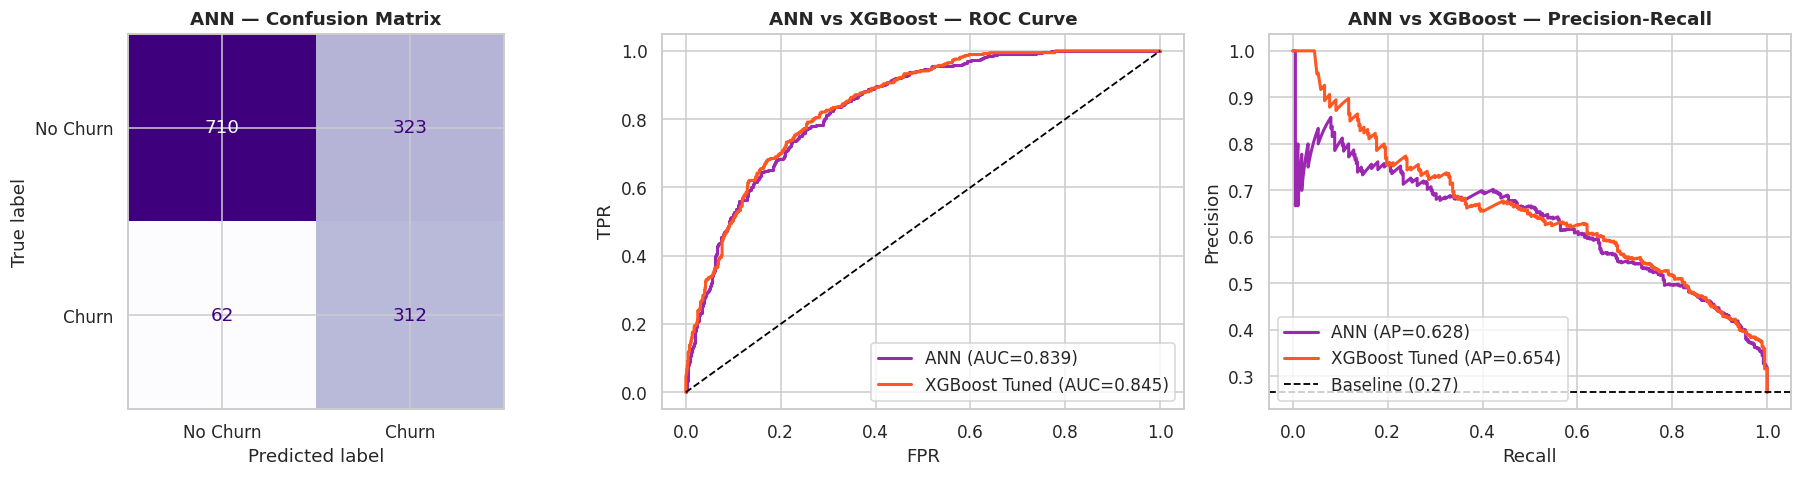

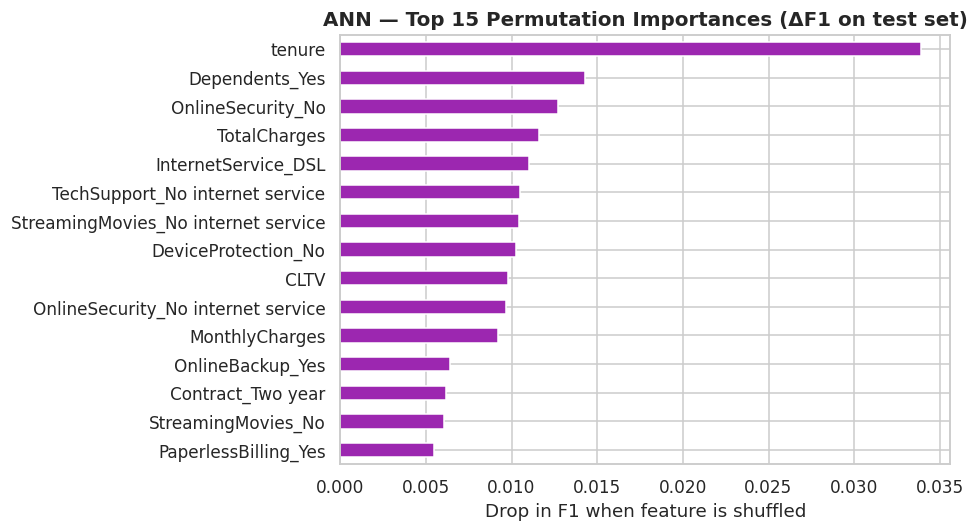

In [42]:
# ANN confusion matrix + ROC + Precision-Recall curves (all vs tuned XGBoost)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

cm_ann = confusion_matrix(y_test, ann_pred)
ConfusionMatrixDisplay(cm_ann, display_labels=['No Churn', 'Churn']).plot(
    ax=axes[0], cmap='Purples', colorbar=False,
)
axes[0].set_title('ANN — Confusion Matrix', fontweight='bold')

# ROC comparison with best ML model
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb_proba)
axes[1].plot(fpr_ann, tpr_ann, color='#9C27B0', lw=2,
             label=f'ANN (AUC={ann_auc:.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, color='#FF5722', lw=2,
             label=f'XGBoost Tuned (AUC={roc_auc_score(y_test, best_xgb_proba):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.2)
axes[1].set_title('ANN vs XGBoost — ROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Precision-Recall comparison (more informative under class imbalance)
pr_ann, rc_ann, _ = precision_recall_curve(y_test, ann_proba)
pr_xgb, rc_xgb, _ = precision_recall_curve(y_test, best_xgb_proba)
axes[2].plot(rc_ann, pr_ann, color='#9C27B0', lw=2,
             label=f'ANN (AP={ann_ap:.3f})')
axes[2].plot(rc_xgb, pr_xgb, color='#FF5722', lw=2,
             label=f'XGBoost Tuned (AP={average_precision_score(y_test, best_xgb_proba):.3f})')
axes[2].axhline(y_test.mean(), color='k', linestyle='--', lw=1.2,
                label=f'Baseline ({y_test.mean():.2f})')
axes[2].set_title('ANN vs XGBoost — Precision-Recall', fontweight='bold')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')

plt.tight_layout()
plt.show()

# -------------------------------
# ANN feature importance via permutation (model-agnostic)
# -------------------------------
# Random Forest gives built-in Gini importances; for the ANN we use permutation
# importance on the test set. This degrades predictions by shuffling one feature
# at a time and measures the drop in F1 — model-agnostic and directly comparable
# across ML and DL models.
def _ann_f1_scorer(y_true, y_pred_proba):
    return f1_score(y_true, (y_pred_proba >= best_thresh).astype(int))

# Simple manual permutation importance (keras is not a sklearn estimator).
rng = np.random.default_rng(SEED)
baseline_f1 = _ann_f1_scorer(y_test, ann_proba)
perm_scores = []
for j, fname in enumerate(feature_names):
    X_perm = X_test_sc.copy()
    X_perm[:, j] = rng.permutation(X_perm[:, j])
    perm_proba = ann.predict(X_perm, verbose=0).flatten()
    perm_scores.append(baseline_f1 - _ann_f1_scorer(y_test, perm_proba))

ann_perm_importance = pd.Series(perm_scores, index=feature_names).sort_values(ascending=False)
top15_ann = ann_perm_importance.head(15)

plt.figure(figsize=(9, 5))
top15_ann.iloc[::-1].plot(kind='barh', color='#9C27B0', edgecolor='white')
plt.title('ANN — Top 15 Permutation Importances (ΔF1 on test set)',
          fontsize=13, fontweight='bold')
plt.xlabel('Drop in F1 when feature is shuffled')
plt.tight_layout()
plt.show()

---
## Final Comparison — ML vs Deep Learning

We compare **all ML variants** (baselines, tuned models, optional feature selection) with the **ANN** using the same test set and metrics.

- **Primary metric for choosing the best model**: **F1-score** (churn is the minority class).
- **Secondary metrics**: Accuracy and ROC-AUC.

The table and chart below summarize results; the following cell highlights the **best model by F1** and explains why it fits this dataset.

In [43]:
# ── Final comparison table (all ML variants + ANN) ─────────────────────────────
# Now includes PR-AUC and measured training / inference time so the claim
# "ML tends to win on tabular data" is backed by numbers rather than intuition.


def _append_model(rows, name, y_pred, y_proba, mtype):
    """Add one row with the same metrics used for ML/DL evaluation."""
    fit_t, pred_t = timing_log.get(name, (np.nan, np.nan))
    rows.append(
        {
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1 Score': f1_score(y_test, y_pred),
            'ROC-AUC': roc_auc_score(y_test, y_proba),
            'PR-AUC': average_precision_score(y_test, y_proba),
            'Train (s)': fit_t,
            'Predict (s)': pred_t,
            'Type': mtype,
        }
    )


_rows = []
_append_model(_rows, 'Logistic Regression', lr_pred, lr_proba, 'ML')
_append_model(_rows, 'Random Forest', rf_pred, rf_proba, 'ML')
_append_model(_rows, 'Random Forest (tuned)', best_rf_pred, best_rf_proba, 'ML')
_append_model(_rows, 'XGBoost', xgb_pred, xgb_proba, 'ML')
_append_model(_rows, 'XGBoost (tuned)', best_xgb_pred, best_xgb_proba, 'ML')
if 'fs_pred' in globals() and 'fs_proba' in globals():
    _append_model(_rows, 'XGBoost (tuned + FS)', fs_pred, fs_proba, 'ML')
_append_model(_rows, 'ANN (Deep Learning)', ann_pred, ann_proba, 'DL')

all_models = pd.DataFrame(_rows)

primary_metric = 'F1 Score'
_best_idx = all_models[primary_metric].idxmax()
best_row = all_models.loc[_best_idx]

print('\n' + '=' * 88)
print('           FINAL MODELS COMPARISON (all ML + ANN)')
print('           Primary metric for choosing the best model: F1-score')
print('=' * 88)
for i, r in all_models.iterrows():
    star = ' *' if i == _best_idx else '  '
    print(
        f"{star} {r['Model']:<24} Acc {r['Accuracy']:.4f}  "
        f"F1 {r['F1 Score']:.4f}  ROC {r['ROC-AUC']:.4f}  PR {r['PR-AUC']:.4f}  "
        f"[{r['Type']}]  train {r['Train (s)']:.2f}s / pred {r['Predict (s)']:.4f}s"
    )
print('=' * 88)
print('* = best model by', primary_metric)
print(
    all_models
    .set_index('Model')[['Accuracy', 'F1 Score', 'ROC-AUC', 'PR-AUC', 'Train (s)', 'Predict (s)']]
    .round(4)
    .to_string()
)
print('=' * 88)


           FINAL MODELS COMPARISON (all ML + ANN)
           Primary metric for choosing the best model: F1-score
   Logistic Regression      Acc 0.7299  F1 0.6082  ROC 0.8426  PR 0.6310  [ML]  train 0.02s / pred 0.0005s
   Random Forest            Acc 0.7918  F1 0.5581  ROC 0.8304  PR 0.6112  [ML]  train 0.34s / pred 0.0677s
   Random Forest (tuned)    Acc 0.7996  F1 0.5889  ROC 0.8424  PR 0.6514  [ML]  train 0.49s / pred 0.1116s
   XGBoost                  Acc 0.7434  F1 0.6243  ROC 0.8424  PR 0.6513  [ML]  train 0.56s / pred 0.0072s
   XGBoost (tuned)          Acc 0.7484  F1 0.6282  ROC 0.8445  PR 0.6544  [ML]  train 0.85s / pred 0.0073s
 * XGBoost (tuned + FS)     Acc 0.7491  F1 0.6304  ROC 0.8446  PR 0.6533  [ML]  train 0.98s / pred 0.0107s
   ANN (Deep Learning)      Acc 0.7264  F1 0.6184  ROC 0.8392  PR 0.6282  [DL]  train 8.88s / pred 0.1892s
* = best model by F1 Score
                       Accuracy  F1 Score  ROC-AUC  PR-AUC  Train (s)  Predict (s)
Model                     

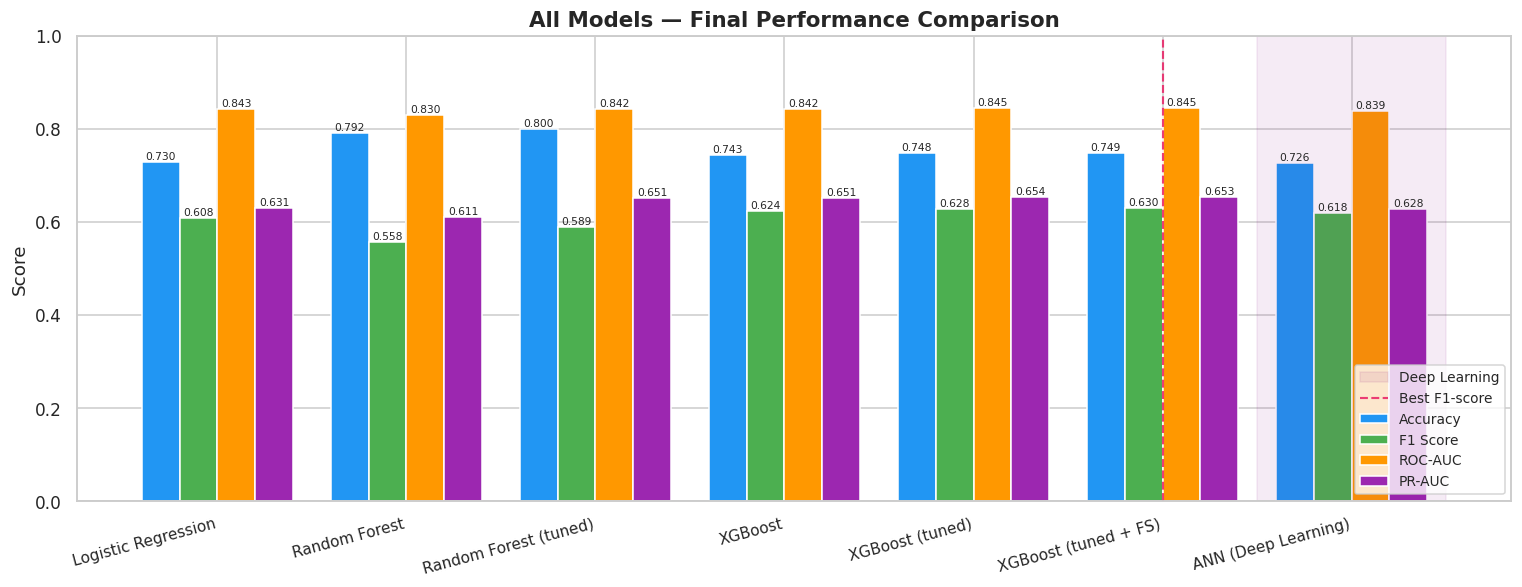

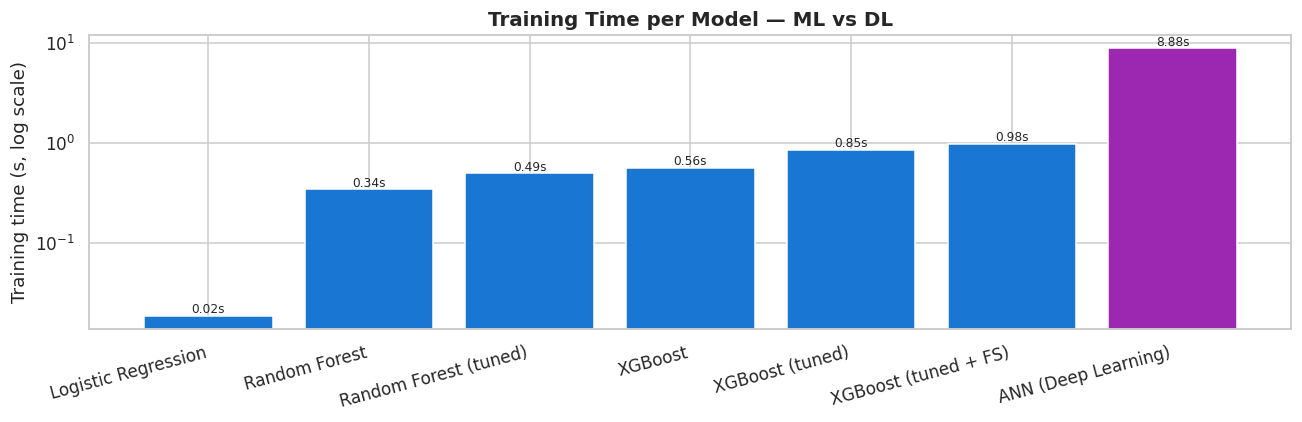

In [44]:
# Final grouped bar chart — includes PR-AUC and uses full 0–1 y-axis so
# imbalanced-class metrics (which can dip below 0.5) are never clipped.
fig, ax = plt.subplots(figsize=(14, 5.5))
x = np.arange(len(all_models))
width = 0.20

b1 = ax.bar(x - 1.5 * width, all_models['Accuracy'], width, label='Accuracy', color='#2196F3', edgecolor='white')
b2 = ax.bar(x - 0.5 * width, all_models['F1 Score'], width, label='F1 Score', color='#4CAF50', edgecolor='white')
b3 = ax.bar(x + 0.5 * width, all_models['ROC-AUC'], width, label='ROC-AUC', color='#FF9800', edgecolor='white')
b4 = ax.bar(x + 1.5 * width, all_models['PR-AUC'], width, label='PR-AUC', color='#9C27B0', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(all_models['Model'], rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models — Final Performance Comparison', fontsize=14, fontweight='bold')
for bar in [*b1, *b2, *b3, *b4]:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=7)

# Shade the DL model bar region.
_dl_idx = int(all_models.index[all_models['Type'] == 'DL'][0])
ax.axvspan(_dl_idx - 0.5, _dl_idx + 0.5, alpha=0.08, color='purple', label='Deep Learning')

_best_idx = int(all_models['F1 Score'].idxmax())
ax.axvline(_best_idx, color='#E91E63', linestyle='--', linewidth=1.4, alpha=0.85,
           label='Best F1-score')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

# Dedicated training-time comparison (log-scale because ANN is typically orders
# of magnitude slower than classical ML on small tabular data).
fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(all_models['Model'], all_models['Train (s)'],
              color=['#9C27B0' if t == 'DL' else '#1976D2' for t in all_models['Type']],
              edgecolor='white')
ax.set_yscale('log')
ax.set_ylabel('Training time (s, log scale)')
ax.set_title('Training Time per Model — ML vs DL', fontsize=13, fontweight='bold')
ax.set_xticklabels(all_models['Model'], rotation=15, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():.2f}s', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [45]:
# Best model by primary metric (F1) + short rationale for this dataset
print('\n' + '=' * 78)
print('BEST MODEL (primary metric: F1-score)')
print('=' * 78)
print(f"  Model        : {best_row['Model']}")
print(f"  Type         : {best_row['Type']}")
print(f"  Accuracy     : {best_row['Accuracy']:.4f}")
print(f"  F1-score     : {best_row['F1 Score']:.4f}")
print(f"  ROC-AUC      : {best_row['ROC-AUC']:.4f}")
print(f"  PR-AUC       : {best_row['PR-AUC']:.4f}")
print(f"  Train time   : {best_row['Train (s)']:.3f}s")
print(f"  Predict time : {best_row['Predict (s)']:.4f}s")
print('-' * 78)
print('Why this model wins here (Telco churn, tabular features):')
print('  • Churn is imbalanced; F1 and PR-AUC focus on the minority class.')
print('  • Tree boosting (e.g. XGBoost) fits interactions among categoricals + numerics')
print('    without hand-crafted feature crosses, which helps on this schema.')
print('  • On medium-sized tabular data, strong ML baselines often match or beat a')
print('    modest ANN while training orders of magnitude faster (see timing chart).')
if best_row['Type'] == 'DL':
    print('  • The ANN reached the best F1 here; threshold tuning (Youden) and class')
    print('    weights helped align it with the same evaluation as ML.')
print('=' * 78)


BEST MODEL (primary metric: F1-score)
  Model        : XGBoost (tuned + FS)
  Type         : ML
  Accuracy     : 0.7491
  F1-score     : 0.6304
  ROC-AUC      : 0.8446
  PR-AUC       : 0.6533
  Train time   : 0.975s
  Predict time : 0.0107s
------------------------------------------------------------------------------
Why this model wins here (Telco churn, tabular features):
  • Churn is imbalanced; F1 and PR-AUC focus on the minority class.
  • Tree boosting (e.g. XGBoost) fits interactions among categoricals + numerics
    without hand-crafted feature crosses, which helps on this schema.
  • On medium-sized tabular data, strong ML baselines often match or beat a
    modest ANN while training orders of magnitude faster (see timing chart).


---
## Conclusion, deployment, and next steps

### Conclusion — when ML vs DL tends to win

| Situation | Prefer |
| --- | --- |
| **Tabular data**, engineered features, **limited** rows | **Classical ML** (linear / trees / boosting): strong baselines, fast iteration, easier interpretation. |
| **Interpretability**, latency, and **simple deployment** | **ML** (e.g. feature importances, linear coefficients, shallow trees). |
| **Larger datasets**, **raw** inputs (text, images), or **complex nonlinear** patterns where hand features are weak | **Deep learning** can learn representations end-to-end. |
| **This project** (structured Telco churn, ~7k rows after cleaning) | Boosted trees (**XGBoost**) often compete with or beat a **small ANN**; the table above shows which approach scored best on **F1** for our split. |

### Practical recommendation for deployment

- Ship the **best-by-F1** model from the final table (often **XGBoost** or its tuned/FS variant here), with **probability outputs** for retention campaigns.
- Enforce the same **preprocessing** as training (encoding, scaling, dropped leakage columns).
- Set **decision thresholds** from business cost (false churn vs missed churn), not only 0.5; Youden’s J is a data-driven starting point.

### Next steps

- **Calibration** (e.g. Platt / isotonic) so predicted churn probabilities align with observed rates.
- **Explainability**: SHAP or permutation importance for global drivers; local explanations for high-risk accounts.
- **Cross-validation** (e.g. stratified *k*-fold) for more stable estimates than a single split.
- **Monitoring**: drift in input distributions and **periodic retraining** on fresh data.
- **Retraining plan**: schedule (e.g. monthly), triggers (performance drop, data change), and versioned artifacts.